In [14]:
# ============================================================
# CELL 1: Import all required libraries
# ============================================================

# BigQuery client library to interact with GCP BigQuery
from google.cloud import bigquery

# Service account credentials to authenticate with GCP
from google.oauth2 import service_account

# Load environment variables from .env / .txt config files
from dotenv import load_dotenv

# Standard libraries
import os
import time
import tqdm  # Progress bar for long-running loops

# Vertex AI SDK for Gemini / embedding models
import vertexai

In [15]:
# ============================================================
# CELL 2: Load credentials and initialize BigQuery client
# ============================================================

# -----------------------------------------------------------
# PROD credentials → used for reading from Discovery Engine API
# DEV  credentials → used for reading/writing BigQuery tables
# -----------------------------------------------------------

# Load PROD environment variables (Discovery Engine / Agent reads)
load_dotenv(r'C:\I&I Work Stuff\agent info\agentspace_env_p.txt', override=True)
PROD_SA  = os.getenv("SERVICE_ACCOUNT")   # Path to PROD service account JSON
PROD_PID = os.getenv("PROJECT_ID")        # PROD GCP Project ID

# Load DEV environment variables (BigQuery writes)
load_dotenv(r'C:\I&I Work Stuff\agent info\agentspace_env_d.txt', override=True)
DEV_SA  = os.getenv("SERVICE_ACCOUNT")    # Path to DEV service account JSON
DEV_PID = os.getenv("PROJECT_ID")         # DEV GCP Project ID

# -----------------------------------------------------------
# Create DEV BigQuery client using service account credentials
# This client will be used for ALL BigQuery operations
# (replaces any previous SQLite connections)
# -----------------------------------------------------------
dev_creds = service_account.Credentials.from_service_account_file(
    DEV_SA,
    scopes=["https://www.googleapis.com/auth/cloud-platform"]  # Full GCP access scope
)

# Initialize BigQuery client — this is our MAIN DB connection
# Think of this like a DB connection object (replacing sqlite3.connect())
bq_client = bigquery.Client(credentials=dev_creds, project=DEV_PID)

# -----------------------------------------------------------
# Confirmation prints to verify everything loaded correctly
# -----------------------------------------------------------
print(f"✅ Prod SA  : {PROD_SA}")
print(f"✅ Prod PID : {PROD_PID}")
print(f"✅ Dev SA   : {DEV_SA}")
print(f"✅ Dev PID  : {DEV_PID}")
print(f"✅ BigQuery client ready → Project: {DEV_PID}")

✅ Prod SA  : C:\I&I Work Stuff\Agentspace_Prod.json
✅ Prod PID : agntspce-agntspace-ai-p-1-18cd
✅ Dev SA   : C:\I&I Work Stuff\Agentspace_DEV.json
✅ Dev PID  : agntspce-agntspace-ai-d-1-eced
✅ BigQuery client ready → Project: agntspce-agntspace-ai-d-1-eced


In [ ]:
# curl -X GET -H "Authorization: Bearer $(gcloud auth print-access-token)" -H "Content-Type: application/json" -H "X-Goog-User-Project: 700562094861" "https://global-discoveryengine.googleapis.com/v1/projects/700562094861/locations/global/userStores/default_user_store/userLicenses"

In [16]:
# ============================================================
# Focused Group Excel → BigQuery Upload (Audit Table)
# ============================================================

import pandas as pd
from pathlib import Path
from google.cloud import bigquery

# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------
EXCEL_PATH = r'C:\\I&I Work Stuff\\agent info\\focused_group.xlsx'

# ✅ Updated table name
BQ_TABLE = f"{DEV_PID}.gemini_exports.tb_gaudit_focused_group"

# ---------------------------------------------------------------
# FUNCTION
# ---------------------------------------------------------------
def load_focused_group_to_bq(excel_path: str, bq_table: str):
    """
    Reads 'focusedgroup' sheet from Excel and uploads
    email_address column to tb_gaudit_focused_group in BigQuery.
    
    - Cleans data (lowercase, remove duplicates, trim spaces)
    - Uses WRITE_TRUNCATE (full refresh)
    """

    # ✅ FIX: use Path instead of string
    abs_path = Path(excel_path).resolve()
    
    if not abs_path.exists():
        print(f"❌ Excel file not found: {abs_path}")
        return

    print(f"📂 Reading Excel: {abs_path}")
    
    # Read Excel sheet
    df = pd.read_excel(abs_path, sheet_name='focusedgroup')
    
    # Clean column names
    df.columns = [c.lower().strip().replace(' ', '_') for c in df.columns]
    
    print(f"📋 Columns found: {df.columns.tolist()}")
    print(f"📊 Total records in Excel: {len(df)}")
    
    # Ensure email column exists
    if 'email_address' not in df.columns:
        email_col = [c for c in df.columns if 'email' in c.lower()]
        if email_col:
            df = df.rename(columns={email_col[0]: 'email_address'})
            print(f"✅ Renamed '{email_col[0]}' → 'email_address'")
        else:
            print(f"❌ Could not find email column. Columns: {df.columns.tolist()}")
            return
    
    # Keep only email column
    df = df[['email_address']].copy()
    
    # Clean data
    df = df.dropna(subset=['email_address'])
    df = df.drop_duplicates(subset=['email_address'])
    df['email_address'] = df['email_address'].astype(str).str.strip().str.lower()
    
    print(f"✅ Clean records to upload: {len(df)}")
    
    # ---------------------------------------------------------------
    # Upload to BigQuery
    # ---------------------------------------------------------------
    job_config = bigquery.LoadJobConfig(
        write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
        schema=[
            bigquery.SchemaField("email_address", "STRING", mode="REQUIRED"),
        ]
    )
    
    print(f"⬆️ Uploading to BigQuery: {bq_table}")
    
    job = bq_client.load_table_from_dataframe(df, bq_table, job_config=job_config)
    job.result()
    
    print(f"✅ Successfully loaded {len(df)} records to {bq_table}")
    
    # ---------------------------------------------------------------
    # Verification
    # ---------------------------------------------------------------
    verify_query = f"SELECT COUNT(*) AS total FROM `{bq_table}`"
    result = bq_client.query(verify_query).result()
    
    for row in result:
        print(f"🔍 Verification - Records in BQ: {row.total}")


# ---------------------------------------------------------------
# RUN
# ---------------------------------------------------------------
load_focused_group_to_bq(EXCEL_PATH, BQ_TABLE)

📂 Reading Excel: C:\I&I Work Stuff\agent info\focused_group.xlsx
📋 Columns found: ['email_address']
📊 Total records in Excel: 65
✅ Clean records to upload: 65
⬆️ Uploading to BigQuery: agntspce-agntspace-ai-d-1-eced.gemini_exports.tb_gaudit_focused_group
✅ Successfully loaded 65 records to agntspce-agntspace-ai-d-1-eced.gemini_exports.tb_gaudit_focused_group
🔍 Verification - Records in BQ: 65


In [17]:
# ============================================================
# Gemini Enterprise License Audit — BigQuery Version (Clean)
# ============================================================
# Logic Summary:
#   - PROD creds  → call Discovery Engine API to fetch licenses
#   - DEV creds   → write results into BigQuery (gemini_exports dataset)
#   - group_indicator : email checked against tb_gaudit_focused_group in BQ
#                       → 'Focused Group' or 'General Population'
#   - claim_status    : based on lastLoginTime (NOT createTime)
#                       → 1 = user has actually logged in (claimed)
#                       → 0 = license assigned but NEVER logged in
#   - BQ write method : WRITE_TRUNCATE via load_table_from_json()
#                       → avoids streaming buffer DELETE lock issue
#   - Only 5 columns  : email_address, date_assigned, last_used,
#                       group_indicator, claim_status
# ============================================================

import os
import json
from typing import Dict, Any, List, Tuple
import requests
from dotenv import load_dotenv
from google.oauth2 import service_account
from google.cloud import bigquery
import google.auth.transport.requests

# ─────────────────────────────────────────────────────────────
# CONFIG — update paths/names if anything changes
# ─────────────────────────────────────────────────────────────
PROD_ENV_PATH = r'C:\I&I Work Stuff\agent info\agentspace_env_p.txt'  # Discovery Engine creds
DEV_ENV_PATH  = r'C:\I&I Work Stuff\agent info\agentspace_env_d.txt'  # BigQuery write creds

BQ_DATASET = "gemini_exports"
BQ_TABLE   = "tb_gaudit_license_assignment"  # main license table
BQ_FOCUSED = "tb_gaudit_focused_group"       # focused group reference table

# Business rules — update if pool size changes
TOTAL_LICENSE_POOL = 500
DEV_RESERVED       = 50

# ─────────────────────────────────────────────────────────────
# STEP 0: Load credentials + create BigQuery client
# PROD creds → Discovery Engine API calls
# DEV creds  → all BigQuery read/write operations
# ─────────────────────────────────────────────────────────────
load_dotenv(PROD_ENV_PATH, override=True)
PROD_SA  = os.getenv("SERVICE_ACCOUNT")
PROD_PID = os.getenv("PROJECT_ID")

load_dotenv(DEV_ENV_PATH, override=True)
DEV_SA  = os.getenv("SERVICE_ACCOUNT")
DEV_PID = os.getenv("PROJECT_ID")

# BQ client uses DEV service account for all BigQuery operations
dev_creds = service_account.Credentials.from_service_account_file(
    DEV_SA,
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)
bq_client = bigquery.Client(credentials=dev_creds, project=DEV_PID)

print(f"✅ PROD SA  : {PROD_SA}")
print(f"✅ PROD PID : {PROD_PID}")
print(f"✅ DEV SA   : {DEV_SA}")
print(f"✅ DEV PID  : {DEV_PID}")
print(f"✅ BQ Client ready → project: {DEV_PID}")


# ─────────────────────────────────────────────────────────────
# STEP 1: Fetch all user licenses from Discovery Engine API
# Uses PROD credentials — returns raw JSON response
# ─────────────────────────────────────────────────────────────
def get_discovery_engine_licenses() -> Dict[str, Any]:
    print("\n🔄 Fetching licenses from Google Discovery Engine...")

    scopes = ['https://www.googleapis.com/auth/cloud-platform']

    # Supports both: file path to SA JSON, or SA JSON as inline string
    if os.path.exists(PROD_SA):
        creds = service_account.Credentials.from_service_account_file(
            PROD_SA, scopes=scopes
        )
    else:
        info  = json.loads(PROD_SA)
        creds = service_account.Credentials.from_service_account_info(
            info, scopes=scopes
        )

    # Refresh to get a valid bearer token for the API call
    creds.refresh(google.auth.transport.requests.Request())

    url = (
        f"https://global-discoveryengine.googleapis.com/v1/projects/"
        f"{PROD_PID}/locations/global/userStores/default_user_store/userLicenses"
    )
    headers = {
        "Authorization"      : f"Bearer {creds.token}",
        "Content-Type"       : "application/json",
        "X-Goog-User-Project": PROD_PID
    }

    response = requests.get(url, headers=headers)
    response.raise_for_status()  # throws if API call fails

    print("✅ Successfully fetched licenses from Discovery Engine.")
    return response.json()


# ─────────────────────────────────────────────────────────────
# STEP 2: Helper — extract YYYY-MM-DD from ISO timestamp
# Returns 'N/A' if timestamp is missing or malformed
# Example: '2024-01-15T10:30:00Z' → '2024-01-15'
# ─────────────────────────────────────────────────────────────
def get_date_from_timestamp(timestamp: str) -> str:
    if not timestamp or 'T' not in timestamp:
        return 'N/A'
    return timestamp.split('T')[0]


# ─────────────────────────────────────────────────────────────
# STEP 3: Save licenses directly into BigQuery
#
# group_indicator logic:
#   → Loads focused group emails from tb_gaudit_focused_group in BQ
#   → If user email matches → 'Focused Group', else → 'General Population'
#
# claim_status logic:
#   → 1 = lastLoginTime exists → user actually LOGGED IN (claimed)
#   → 0 = no lastLoginTime    → assigned but NEVER logged in
#   → createTime (date_assigned) is NOT used — it's always present
#     for ASSIGNED users, which would make everyone claim_status=1 (wrong!)
#
# BQ write strategy — WRITE_TRUNCATE via load_table_from_json():
#   → Replaces entire table in one atomic operation
#   → Avoids the streaming buffer lock that blocks DELETE + insert_rows_json
# ─────────────────────────────────────────────────────────────
def save_licenses_to_bq(license_data: Dict[str, Any]):
    print("\n🔄 Preparing license records for BigQuery...")

    # ── Load focused group emails from BQ for group tagging ──────
    # Used to tag each user as 'Focused Group' or 'General Population'
    focused_result = bq_client.query(f"""
        SELECT email_address 
        FROM `{DEV_PID}.{BQ_DATASET}.{BQ_FOCUSED}`
    """).result()

    # Store as a set for O(1) lookup during row building
    focused_emails = {row.email_address for row in focused_result}
    print(f"   → Loaded {len(focused_emails)} emails from tb_gaudit_focused_group")

    # ── Build rows from API response ─────────────────────────────
    rows_to_insert: List[Dict] = []

    for user in license_data.get('userLicenses', []):
        # Only process ASSIGNED licenses — skip UNASSIGNED or any other state
        if user.get('licenseAssignmentState') != 'ASSIGNED':
            continue

        email         = user.get('userPrincipal', 'N/A')
        date_assigned = get_date_from_timestamp(user.get('createTime'))     # when license was given
        last_used     = get_date_from_timestamp(user.get('lastLoginTime'))  # when they last logged in

        # group_indicator: tag based on tb_gaudit_focused_group lookup in BQ
        group_indicator = 'Focused Group' if email in focused_emails else 'General Population'

        # claim_status: 1 only if user has actually logged in (lastLoginTime present)
        # We do NOT use date_assigned/createTime — always present for ASSIGNED = always 1 = wrong
        claim_status = 1 if last_used != 'N/A' else 0

        rows_to_insert.append({
            "email_address"  : email,
            "date_assigned"  : date_assigned,   # STRING: YYYY-MM-DD or 'N/A'
            "last_used"      : last_used,        # STRING: YYYY-MM-DD or 'N/A'
            "group_indicator": group_indicator,  # STRING: 'Focused Group' / 'General Population'
            "claim_status"   : claim_status      # INTEGER: 1 = claimed, 0 = not claimed
        })

    if not rows_to_insert:
        print("⚠️  No ASSIGNED licenses found. Nothing to insert.")
        return

    print(f"   → {len(rows_to_insert)} ASSIGNED license records ready")

    # ── Write to BigQuery using WRITE_TRUNCATE ────────────────────
    # load_table_from_json() with WRITE_TRUNCATE replaces the whole table atomically
    # This avoids the streaming buffer lock error from DELETE + insert_rows_json
    full_table_id = f"{DEV_PID}.{BQ_DATASET}.{BQ_TABLE}"

    # Define the exact schema — must match your BQ table definition
    job_config = bigquery.LoadJobConfig(
        schema=[
            bigquery.SchemaField("email_address",   "STRING"),
            bigquery.SchemaField("date_assigned",   "STRING"),
            bigquery.SchemaField("last_used",       "STRING"),
            bigquery.SchemaField("group_indicator", "STRING"),
            bigquery.SchemaField("claim_status",    "INTEGER"),
        ],
        # WRITE_TRUNCATE = delete all existing rows + write new ones in one shot
        write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
    )

    # Load the list of dicts directly into BQ — no temp file needed
    load_job = bq_client.load_table_from_json(
        rows_to_insert,
        full_table_id,
        job_config=job_config
    )
    load_job.result()  # wait for the job to finish

    # Check for any errors during the load job
    if load_job.errors:
        print(f"❌ BigQuery load errors: {load_job.errors}")
    else:
        print(f"✅ Inserted {len(rows_to_insert)} records into {full_table_id} (WRITE_TRUNCATE)")


# ─────────────────────────────────────────────────────────────
# STEP 4: BQ query helper — runs COUNT(*) query, returns int
# Replaces the old SQLite extract_data() function
# ─────────────────────────────────────────────────────────────
def extract_data_bq(sql: str) -> int:
    # Runs any COUNT(*) SQL against BQ and returns the integer result
    result = bq_client.query(sql).result()
    for row in result:
        return int(row[0])  # COUNT(*) → first column of first row
    return 0  # fallback if no rows returned


# ─────────────────────────────────────────────────────────────
# STEP 5: Calculate all license stats from BigQuery
#
# Pool breakdown logic:
#   Total Pool (500)
#   ├── Dev Reserved              : fixed 50 slots (business rule)
#   ├── General Population        : has license + NOT in tb_gaudit_focused_group
#   ├── General Pop (never used)  : general + claim_status = 0
#   ├── Focused Group             : in tb_gaudit_focused_group + has license row
#   ├── FG (never logged in)      : in FG + has license + claim_status = 0
#   ├── FG Not Claimed            : in tb_gaudit_focused_group + NO license row at all
#   └── Available                 : 500 - total_assigned - dev - FG_not_claimed
#
# NOTE: tbl and tfg are plain strings (no backticks here)
#       backticks are added inside each query string below
# ─────────────────────────────────────────────────────────────
def calculate_license_stats() -> Tuple[Dict, int]:
    print("\n🔄 Calculating license stats from BigQuery...")

    # Full table paths — used directly inside f-string queries with backticks
    tbl = f"{DEV_PID}.{BQ_DATASET}.{BQ_TABLE}"    # tb_license_assignments
    tfg = f"{DEV_PID}.{BQ_DATASET}.{BQ_FOCUSED}"  # tb_gaudit_focused_group

    # Total rows in tb_license_assignments (all ASSIGNED users from API)
    total_assignment = extract_data_bq(
        f"SELECT COUNT(*) FROM `{tbl}`"
    )

    # General Population = has a license row AND NOT in focused group table
    general_population = extract_data_bq(f"""
        SELECT COUNT(*) FROM `{tbl}`
        WHERE email_address NOT IN (
            SELECT email_address FROM `{tfg}`
        )
    """)

    # General Population never logged in = general users with claim_status = 0
    general_not_claimed = extract_data_bq(f"""
        SELECT COUNT(*) FROM `{tbl}`
        WHERE email_address NOT IN (
            SELECT email_address FROM `{tfg}`
        )
        AND claim_status = 0
    """)

    # Focused Group WITH license = in tb_gaudit_focused_group AND has a license row
    focused_group = extract_data_bq(f"""
        SELECT COUNT(*) FROM `{tfg}`
        WHERE email_address IN (
            SELECT email_address FROM `{tbl}`
        )
    """)

    # Focused Group NO license yet = in tb_gaudit_focused_group but NO license row at all
    focused_not_claimed = extract_data_bq(f"""
        SELECT COUNT(*) FROM `{tfg}`
        WHERE email_address NOT IN (
            SELECT email_address FROM `{tbl}`
        )
    """)

    # Focused Group has license but NEVER logged in = has row but claim_status = 0
    focused_not_logged_in = extract_data_bq(f"""
        SELECT COUNT(*) FROM `{tbl}`
        WHERE email_address IN (
            SELECT email_address FROM `{tfg}`
        )
        AND claim_status = 0
    """)

    # License pool math
    yet_to_allocate = focused_not_claimed  # FG slots reserved but not yet assigned
    available       = TOTAL_LICENSE_POOL - (total_assignment + DEV_RESERVED + yet_to_allocate)
    total_license   = general_population + DEV_RESERVED + focused_group + available + yet_to_allocate

    stats = {
        "generalPopulation"         : general_population,
        "generalPopulation_NotUsed" : general_not_claimed,    # have license, never logged in
        "AllocatedToDev"            : DEV_RESERVED,
        "FocusedGroup"              : focused_group,           # in FG + has license
        "FocusedGroup_NotLoggedIn"  : focused_not_logged_in,  # in FG + has license + never used
        "FocusedGroup_NotClaimed"   : focused_not_claimed,    # in FG + NO license at all
        "AvailableLicense"          : available,
        "NotClaimed"                : yet_to_allocate,
        "TotalLicense"              : total_license
    }
    return stats, total_assignment


# ─────────────────────────────────────────────────────────────
# MAIN — runs all steps in sequence
# ─────────────────────────────────────────────────────────────
def main():
    print("=" * 60)
    print("   Gemini Enterprise License Audit — BigQuery Mode")
    print("=" * 60)

    try:
        # 1️⃣ Fetch fresh license data from Discovery Engine API (PROD)
        license_data = get_discovery_engine_licenses()

        # 2️⃣ Write directly to BigQuery using WRITE_TRUNCATE (no SQLite, no DELETE lock)
        save_licenses_to_bq(license_data)

        # 3️⃣ Query BigQuery for all license stats
        stats, total_assignment = calculate_license_stats()

        # 4️⃣ Print results
        print(f"\n📊 Total Assignments                          : {total_assignment}")

        if stats["AvailableLicense"] < 0:
            print("⚠️  Issue with License Allocation!")
            print(stats)
        else:
            print("✅ License Stats:")
            print(f"   {'General Population':<45}: {stats['generalPopulation']}")
            print(f"   {'General Population (never logged in)':<45}: {stats['generalPopulation_NotUsed']}")
            print(f"   {'Allocated to Dev':<45}: {stats['AllocatedToDev']}")
            print(f"   {'Focused Group (has license)':<45}: {stats['FocusedGroup']}")
            print(f"   {'Focused Group (has license, never logged in)':<45}: {stats['FocusedGroup_NotLoggedIn']}")
            print(f"   {'Focused Group (no license yet)':<45}: {stats['FocusedGroup_NotClaimed']}")
            print(f"   {'Available Licenses':<45}: {stats['AvailableLicense']}")
            print(f"   {'Total License':<45}: {stats['TotalLicense']}")

    except Exception as e:
        print(f"\n❌ Fatal Error: {e}")
        raise  # show full traceback in Jupyter

    print("\n" + "=" * 60)
    print("   Audit Complete ✅")
    print("=" * 60)


# Run it!
main()

✅ PROD SA  : C:\I&I Work Stuff\Agentspace_Prod.json
✅ PROD PID : agntspce-agntspace-ai-p-1-18cd
✅ DEV SA   : C:\I&I Work Stuff\Agentspace_DEV.json
✅ DEV PID  : agntspce-agntspace-ai-d-1-eced
✅ BQ Client ready → project: agntspce-agntspace-ai-d-1-eced
   Gemini Enterprise License Audit — BigQuery Mode

🔄 Fetching licenses from Google Discovery Engine...
✅ Successfully fetched licenses from Discovery Engine.

🔄 Preparing license records for BigQuery...
   → Loaded 65 emails from tb_gaudit_focused_group
   → 435 ASSIGNED license records ready
✅ Inserted 435 records into agntspce-agntspace-ai-d-1-eced.gemini_exports.tb_gaudit_license_assignment (WRITE_TRUNCATE)

🔄 Calculating license stats from BigQuery...

📊 Total Assignments                          : 435
✅ License Stats:
   General Population                           : 377
   General Population (never logged in)         : 7
   Allocated to Dev                             : 50
   Focused Group (has license)                  : 58
   Focu


🔄 Calculating license stats from BigQuery...


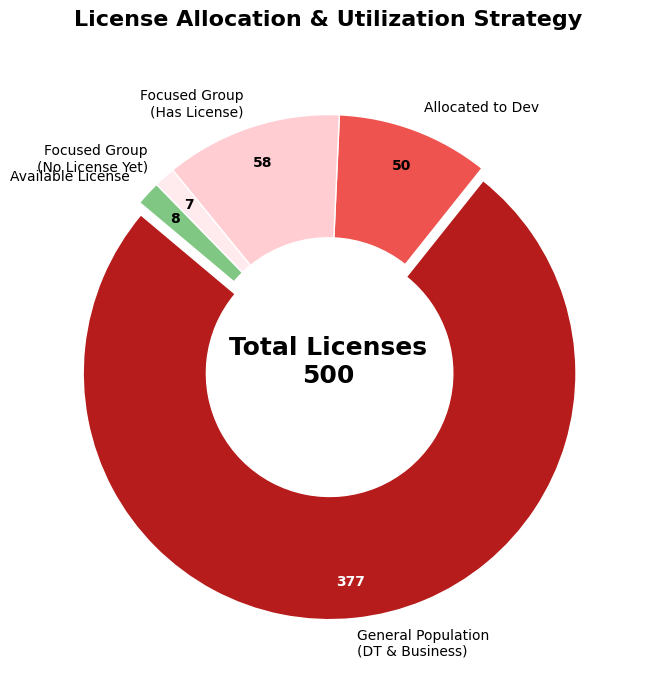


📊 Chart saved as license_allocation_breakdown.png


In [18]:
# ============================================================
# Visualization — Doughnut Chart (BigQuery stats version)
# ============================================================
# Reads from stats dict returned by calculate_license_stats()
# Run this cell AFTER the main audit cell above has completed
# ============================================================
import matplotlib.pyplot as plt

# ── Pull fresh stats from BigQuery ───────────────────────────
# Calling calculate_license_stats() again so this cell works standalone
stats, total_assignment = calculate_license_stats()

# ── Map stats to chart segments ──────────────────────────────
# Each segment = one slice of the 500 license pool
labels = [
    'General Population\n(DT & Business)',
    'Allocated to Dev',
    'Focused Group\n(Has License)',
    'Focused Group\n(No License Yet)',
    'Available License'
]

sizes = [
    stats['generalPopulation'],      # general users with license
    stats['AllocatedToDev'],         # fixed dev reserved slots
    stats['FocusedGroup'],           # FG members who have a license
    stats['FocusedGroup_NotClaimed'],# FG members with NO license yet
    stats['AvailableLicense']        # remaining open slots
]

# ── Colors — red theme + green for available ─────────────────
colors = [
    '#B71C1C',  # Dark Red    → General Population
    '#EF5350',  # Medium Red  → Dev Reserved
    '#FFCDD2',  # Light Red   → Focused Group (has license)
    '#FFEBEE',  # Very Light  → FG Not Claimed
    '#81C784'   # Green       → Available
]

# ── Build doughnut chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    # Show absolute numbers (not percentages) on each slice
    autopct=lambda p: '{:.0f}'.format(p * TOTAL_LICENSE_POOL / 100),
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    explode=(0.05, 0, 0, 0, 0),            # slightly pull out General Population slice
    wedgeprops={'width': 0.5, 'edgecolor': 'w'}  # doughnut style
)

# ── Text styling ─────────────────────────────────────────────
plt.setp(autotexts, size=10, weight="bold")
autotexts[0].set_color('white')   # white text on dark red slice
for i in [1, 2, 3, 4]:
    autotexts[i].set_color('black')

# Center label showing total pool size
ax.text(
    0, 0,
    f'Total Licenses\n{TOTAL_LICENSE_POOL}',
    ha='center', va='center',
    fontsize=18, fontweight='bold'
)

plt.title('License Allocation & Utilization Strategy', pad=20, fontsize=16, fontweight='bold')

# Save + show
plt.savefig('license_allocation_breakdown.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\n📊 Chart saved as license_allocation_breakdown.png")  

In [19]:
# ─────────────────────────────────────────────────────────────
# User Categorization by Last Login — BigQuery Version
# Categorizes General Population users based on how recently
# they last logged in (used their Gemini license)
#
# Categories:
#   'Never Used'       → last_used is 'N/A' (never logged in)
#   '1 Month'          → logged in within last 30 days
#   'More than a Month'→ logged in but more than 30 days ago
#
# Only General Population users are counted here
# (Focused Group is excluded — they're tracked separately)
# ─────────────────────────────────────────────────────────────

def get_user_categorization() -> None:
    """
    Runs a BigQuery query to categorize General Population users
    by how recently they used their Gemini license.
    Prints the result as a clean table.
    """

    # Full table references
    tbl = f"`{DEV_PID}.{BQ_DATASET}.{BQ_TABLE}`"   # tb_license_assignments
    tfg = f"`{DEV_PID}.{BQ_DATASET}.{BQ_FOCUSED}`" # tb_gaudit_focused_group

    # BigQuery version of the categorization query
    # DATE_DIFF replaces SQLite's julianday() for date difference calculation
    # SAFE.PARSE_DATE handles 'N/A' strings gracefully (returns NULL instead of error)
    bq_sql = f"""
        SELECT
            categories,
            user_count
        FROM (
            SELECT
                -- Bucket users by how long ago they last logged in
                CASE
                    WHEN days_since_last_use IS NULL THEN 'Never Used'
                    WHEN days_since_last_use <= 30   THEN '1 Month'
                    ELSE 'More than a Month'
                END AS categories,

                -- Used for ORDER BY so results come out in logical order
                CASE
                    WHEN days_since_last_use IS NULL THEN 6
                    WHEN days_since_last_use <= 30   THEN 1
                    ELSE 6
                END AS month_multiplier,

                COUNT(*) AS user_count

            FROM (
                SELECT
                    email_address,

                    -- DATE_DIFF calculates days between last login and today
                    -- SAFE.PARSE_DATE won't crash if last_used = 'N/A' → returns NULL
                    -- NULL days_since_last_use → 'Never Used' bucket above
                    DATE_DIFF(
                        CURRENT_DATE(),
                        SAFE.PARSE_DATE('%Y-%m-%d', NULLIF(last_used, 'N/A')),
                        DAY
                    ) AS days_since_last_use

                FROM {tbl}

                -- Only General Population (exclude focused group)
                WHERE email_address NOT IN (
                    SELECT email_address FROM {tfg}
                )
            )
            GROUP BY categories, month_multiplier
        )
        ORDER BY month_multiplier ASC
    """

    print("\n🔄 Running user categorization query...")

    # Execute the query and fetch results
    result = bq_client.query(bq_sql).result()

    # Print results as a clean table
    print("\n📊 General Population — Usage Categorization:")
    print(f"   {'Category':<25} {'User Count':>10}")
    print(f"   {'-'*25} {'-'*10}")

    for row in result:
        print(f"   {row['categories']:<25} {row['user_count']:>10}")

    print()  # spacing

# ─────────────────────────────────────────────────────────────
# Run it — call after main() or standalone
# ─────────────────────────────────────────────────────────────
get_user_categorization()


🔄 Running user categorization query...

📊 General Population — Usage Categorization:
   Category                  User Count
   ------------------------- ----------
   1 Month                          336
   More than a Month                 34
   Never Used                         7



In [20]:
# ─────────────────────────────────────────────────────────────
# User Categorization Query — BigQuery Version
# Categorizes General Population users by how recently they logged in
# Uses DATE_DIFF instead of julianday (SQLite) for BigQuery compatibility
# ─────────────────────────────────────────────────────────────

my_sql = f"""
SELECT 
    categories,
    user_count
FROM (
    SELECT 
        CASE 
            WHEN last_used IS NULL OR last_used = 'N/A' THEN 'Never Used'
            WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', last_used), DAY) <= 30 THEN '1 Month'
            ELSE 'More than a Month'
        END AS categories,

        -- month_multiplier used only for ORDER BY (controls sort order in output)
        CASE 
            WHEN last_used IS NULL OR last_used = 'N/A' THEN 6
            WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', last_used), DAY) <= 30 THEN 1
            ELSE 3
        END AS month_multiplier,

        COUNT(*) AS user_count

    FROM (
        SELECT 
            tla.email_address,
            tla.last_used
        FROM `{DEV_PID}.{BQ_DATASET}.{BQ_TABLE}` tla
        -- Only General Population (exclude focused group)
        WHERE tla.email_address NOT IN (
            SELECT email_address FROM `{DEV_PID}.{BQ_DATASET}.{BQ_FOCUSED}`
        )
    )
    GROUP BY categories, month_multiplier
)
ORDER BY month_multiplier ASC;
"""

📊 Raw data from BigQuery:
[
    {
        "categories": "1 Month",
        "user_count": 336
    },
    {
        "categories": "More than a Month",
        "user_count": 34
    },
    {
        "categories": "Never Used",
        "user_count": 7
    }
]


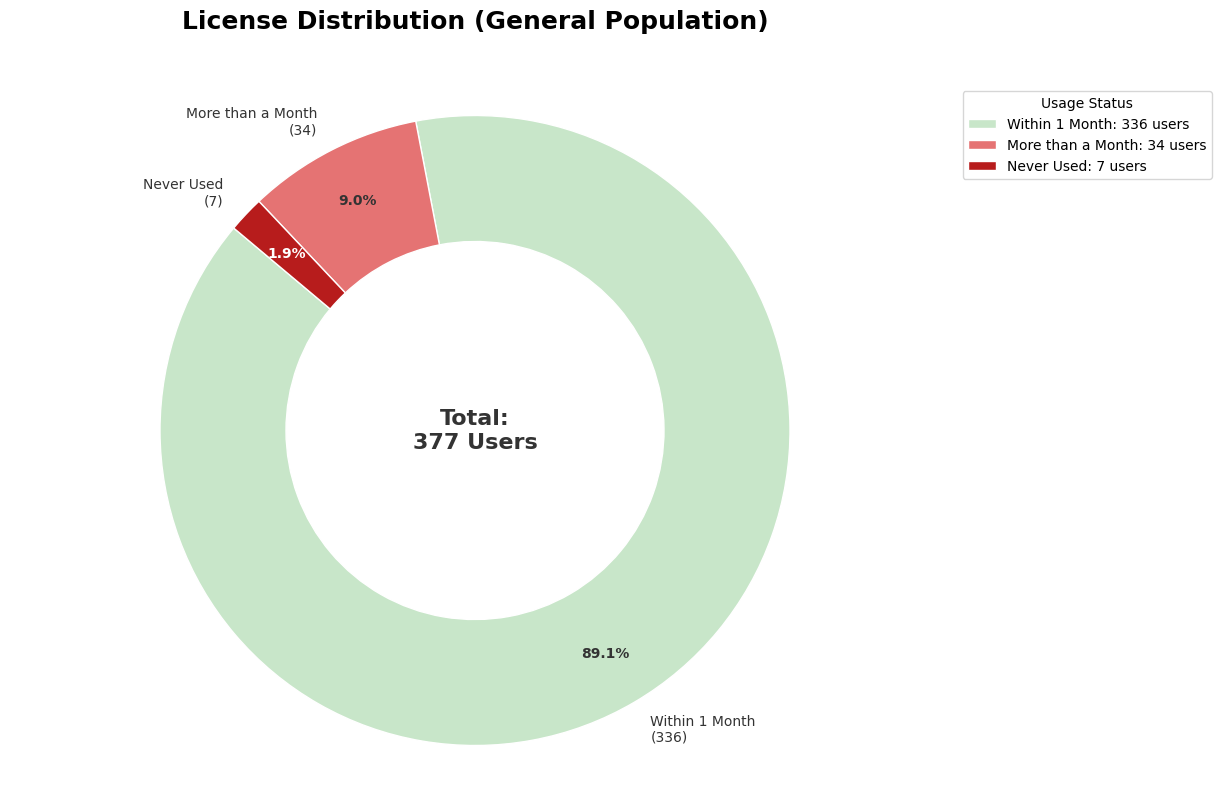

In [21]:
# ─────────────────────────────────────────────────────────────
# Visualization — General Population License Distribution
# Converted from SQLite to BigQuery
# Shows how recently General Population users have logged in
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import json

# ── Pull data from BigQuery using the query defined above ────
# Runs my_sql against BQ and converts result rows to a list of dicts
query_job = bq_client.query(my_sql)
results   = query_job.result()

# Convert BQ rows → list of dicts (same format as old execute_and_format_json)
json_data = [dict(row) for row in results]
print("📊 Raw data from BigQuery:")
print(json.dumps(json_data, indent=4))

# ── Map categories to counts ──────────────────────────────────
# Build a lookup dict: { 'Never Used': 120, '1 Month': 200, ... }
data_map = {item['categories']: item['user_count'] for item in json_data}

# Define strict category order for the chart
categories  = ['Within 1 Month', 'More than a Month', 'Never Used']

# Map BQ result keys to chart order — default 0 if category missing
user_counts = [
    data_map.get("1 Month", 0),            # active users (logged in within 30 days)
    data_map.get("More than a Month", 0),  # inactive users
    data_map.get("Never Used", 0)          # never logged in at all
]

total_users = sum(user_counts)

# ── Color scheme ──────────────────────────────────────────────
# Green = active, Soft Red = inactive, Dark Red = never used
colors = [
    '#C8E6C9',  # Green  (Within 1 Month)
    '#E57373',  # Soft Red (More than a Month)
    '#B71C1C'   # Dark Red (Never Used)
]

# Labels for legend and chart slices
legend_labels = [f"{cat}: {count} users" for cat, count in zip(categories, user_counts)]
chart_labels  = [f"{cat}\n({count})"     for cat, count in zip(categories, user_counts)]

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))

wedges, texts, autotexts = ax.pie(
    user_counts,
    labels=chart_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.82,
    labeldistance=1.1,
    wedgeprops={'width': 0.4, 'edgecolor': 'w'}
)

# ── Text styling ──────────────────────────────────────────────
# White text on dark red slice, dark text on lighter slices
for i, a in enumerate(autotexts):
    a.set_color("white" if i == 2 else "#333333")
    a.set_size(10)
    a.set_weight("bold")

plt.setp(texts, size=10, color="#333333")

# Center text showing total users
ax.text(
    0, 0,
    f'Total:\n{total_users} Users',
    ha='center', va='center',
    fontsize=16, fontweight='bold', color='#333333'
)

# Legend top-right
ax.legend(
    wedges, legend_labels,
    title="Usage Status",
    loc="upper right",
    bbox_to_anchor=(1.3, 1)
)

ax.axis('equal')
plt.title(
    'License Distribution (General Population)',
    pad=40, fontsize=18, fontweight='bold'
)

# Save + show
plt.savefig('license_distribution_general_popu.png', bbox_inches='tight', dpi=300)
plt.show()

✅ Cost query complete:
   1 Month             : 336 users | $8,400
   2 Months            : 14 users | $700
   3 Months            : 11 users | $825
   4 Months            : 3 users | $300
   5 Months            : 2 users | $250
   Over 6 Months       : 2 users | $300
   6 Months            : 2 users | $300
   Never Used          : 7 users | $1,050


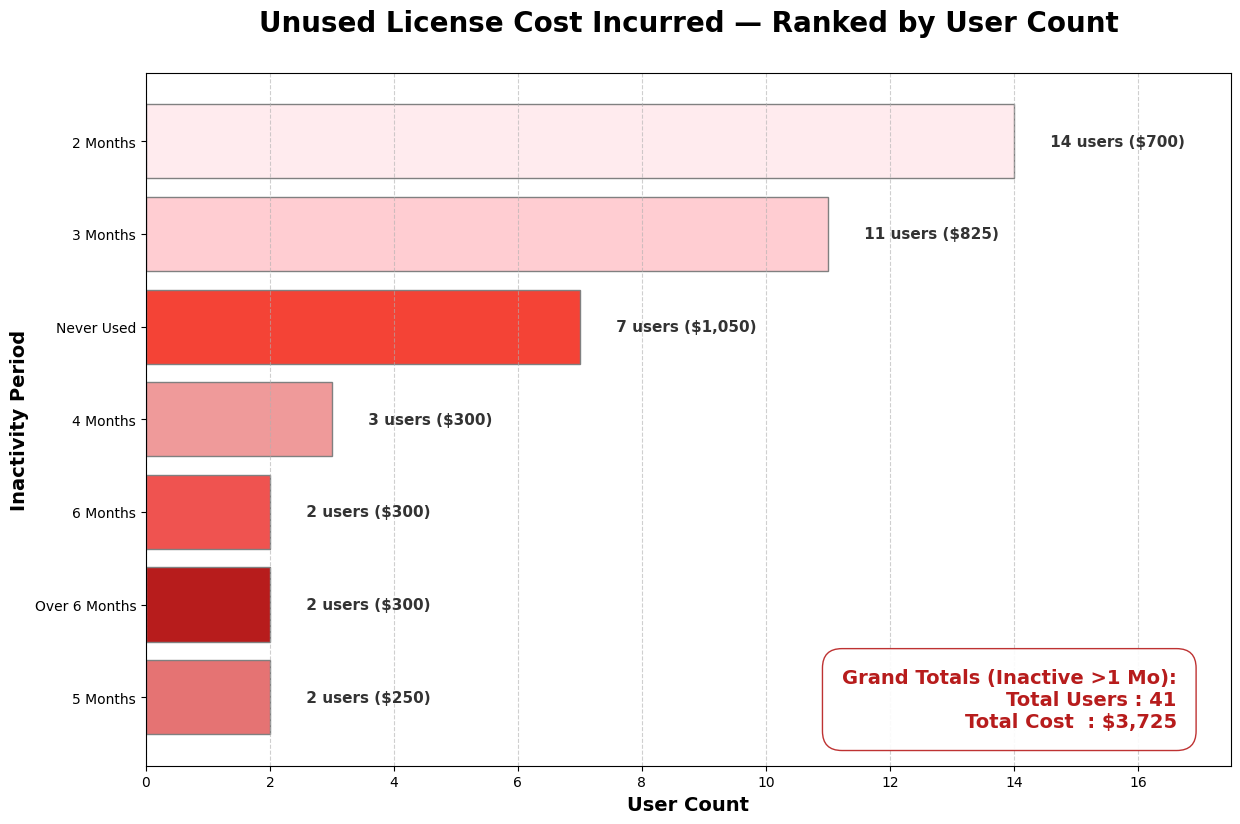


📊 Chart saved → license_usage_general_pop_hbar.png


In [22]:
# ============================================================
# Cost Savings Query + Bar Chart — BigQuery Version
#
# Logic:
#   - Buckets users by inactivity period (1M → 6M+ / Never)
#   - Excludes active users (≤ 30 days) from cost calc
#   - Cost formula: $25 × month_multiplier × user_count
#   - last_used stored as STRING → use SAFE.PARSE_DATE to convert
#   - General Population only (excludes focused group)
# ============================================================
import matplotlib.pyplot as plt

# Full BQ table references
tbl = f"`{DEV_PID}.{BQ_DATASET}.{BQ_TABLE}`"
tfg = f"`{DEV_PID}.{BQ_DATASET}.{BQ_FOCUSED}`"

# ── Cost savings query ────────────────────────────────────
cost_query = f"""
SELECT
    bucket,
    user_count,
    month_multiplier,
    -- Cost formula: $25 per license × months inactive × user count
    25 * month_multiplier * user_count AS potential_savings
FROM (
    SELECT
        CASE
            WHEN last_used = 'N/A' OR last_used IS NULL
                                                    THEN 'Never Used'
            WHEN days_inactive <= 30               THEN '1 Month'
            WHEN days_inactive <= 60               THEN '2 Months'
            WHEN days_inactive <= 90               THEN '3 Months'
            WHEN days_inactive <= 120              THEN '4 Months'
            WHEN days_inactive <= 150              THEN '5 Months'
            WHEN days_inactive <= 180              THEN '6 Months'
            ELSE                                        'Over 6 Months'
        END AS bucket,

        CASE
            WHEN last_used = 'N/A' OR last_used IS NULL THEN 6
            WHEN days_inactive <= 30               THEN 1
            WHEN days_inactive <= 60               THEN 2
            WHEN days_inactive <= 90               THEN 3
            WHEN days_inactive <= 120              THEN 4
            WHEN days_inactive <= 150              THEN 5
            WHEN days_inactive <= 180              THEN 6
            ELSE                                        6
        END AS month_multiplier,

        COUNT(*) AS user_count

    FROM (
        SELECT
            email_address,
            last_used,
            -- Calculate days since last login (NULL-safe)
            CASE
                WHEN last_used = 'N/A' OR last_used IS NULL THEN NULL
                ELSE DATE_DIFF(
                    CURRENT_DATE(),
                    SAFE.PARSE_DATE('%Y-%m-%d', last_used),
                    DAY
                )
            END AS days_inactive
        FROM {tbl}
        -- General Population only
        WHERE email_address NOT IN (
            SELECT email_address FROM {tfg}
        )
    )
    GROUP BY bucket, month_multiplier
)
ORDER BY month_multiplier ASC
"""

# ── Execute query ─────────────────────────────────────────
cost_result = bq_client.query(cost_query).result()

raw_data = [
    {
        "bucket"            : row.bucket,
        "user_count"        : row.user_count,
        "month_multiplier"  : row.month_multiplier,
        "potential_savings" : row.potential_savings
    }
    for row in cost_result
]

print("✅ Cost query complete:")
for item in raw_data:
    print(f"   {item['bucket']:<20}: {item['user_count']} users | ${item['potential_savings']:,}")

# ── Filter out active users (1 Month) from chart ──────────
# Active users aren't a cost concern — only show inactive
filtered_data = [item for item in raw_data if item['bucket'] != '1 Month']

# ── Color map per bucket ──────────────────────────────────
color_map = {
    '2 Months'     : '#FFEBEE',
    '3 Months'     : '#FFCDD2',
    '4 Months'     : '#EF9A9A',
    '5 Months'     : '#E57373',
    '6 Months'     : '#EF5350',
    'Never Used'   : '#F44336',
    'Over 6 Months': '#B71C1C'
}

# ── Prepare sorted data for chart ─────────────────────────
# Sort ascending by user_count so highest bar is at top
chart_data = sorted(
    [
        (
            item['bucket'],
            item['user_count'],
            item['potential_savings'],
            color_map.get(item['bucket'], '#9E9E9E')
        )
        for item in filtered_data
    ],
    key=lambda x: x[1],   # sort by user_count
    reverse=False          # ascending → highest at top of horizontal bar
)

sorted_categories = [x[0] for x in chart_data]
sorted_counts     = [x[1] for x in chart_data]
sorted_savings    = [x[2] for x in chart_data]
sorted_colors     = [x[3] for x in chart_data]

total_count   = sum(sorted_counts)
total_savings = sum(sorted_savings)

# ── Plot Horizontal Bar Chart ─────────────────────────────
plt.figure(figsize=(14, 9))
bars = plt.barh(sorted_categories, sorted_counts, color=sorted_colors, edgecolor='grey')

# Add count + savings label on each bar
for i, (count, save) in enumerate(zip(sorted_counts, sorted_savings)):
    plt.text(
        count + 0.5, i,
        f' {count} users (${save:,})',
        va='center', fontsize=11, fontweight='bold', color='#333333'
    )

# Summary box (bottom right)
summary_text = (
    f"Grand Totals (Inactive >1 Mo):\n"
    f"Total Users : {total_count}\n"
    f"Total Cost  : ${total_savings:,}"
)
plt.text(
    0.95, 0.05, summary_text,
    transform=plt.gca().transAxes,
    fontsize=14, fontweight='bold', color='#B71C1C',
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='#B71C1C', boxstyle='round,pad=1'),
    ha='right', va='bottom'
)

# ── Chart formatting ──────────────────────────────────────
plt.title('Unused License Cost Incurred — Ranked by User Count', fontsize=20, fontweight='bold', pad=30)
plt.xlabel('User Count', fontsize=14, fontweight='bold')
plt.ylabel('Inactivity Period', fontsize=14, fontweight='bold')
plt.xlim(0, max(sorted_counts) + (max(sorted_counts) * 0.25))  # padding for labels
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.savefig('license_usage_general_pop_hbar.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\n📊 Chart saved → license_usage_general_pop_hbar.png")

In [23]:
# ============================================================
# Cost Analysis — Unused License Savings (General Population)
# BigQuery Version
#
# Logic:
#   - Calculates days since last login using DATE_DIFF (BQ syntax)
#   - Buckets users by inactivity period (1M, 2M ... 6M+, Never Used)
#   - Potential savings = $25 × month_multiplier × user_count
#   - Only General Population (NOT in tb_gaudit_focused_group)
#   - "1 Month" bucket is excluded from the chart (active users)
# ============================================================

import json
import matplotlib.pyplot as plt
from google.cloud import bigquery

# ── BigQuery SQL — replaces the old SQLite my_sql ──────────────
# julianday() is SQLite only → use DATE_DIFF(CURRENT_DATE, date, DAY) in BQ
# CAST(last_used AS DATE) needed because last_used is stored as STRING

cost_sql = f"""
SELECT
    bucket,
    user_count,
    -- Potential savings = $25 per license × inactivity multiplier × users
    CONCAT('$', CAST(25 * month_multiplier * user_count AS STRING)) AS potential_savings
FROM (
    SELECT
        -- Bucket users by how long since they last logged in
        CASE
            WHEN days_since_last_use IS NULL THEN 'Never Used'
            WHEN days_since_last_use <= 30   THEN '1 Month'
            WHEN days_since_last_use <= 60   THEN '2 Months'
            WHEN days_since_last_use <= 90   THEN '3 Months'
            WHEN days_since_last_use <= 120  THEN '4 Months'
            WHEN days_since_last_use <= 150  THEN '5 Months'
            WHEN days_since_last_use <= 180  THEN '6 Months'
            ELSE 'Over 6 Months'
        END AS bucket,

        -- Numeric multiplier used in cost formula
        CASE
            WHEN days_since_last_use IS NULL THEN 6
            WHEN days_since_last_use <= 30   THEN 1
            WHEN days_since_last_use <= 60   THEN 2
            WHEN days_since_last_use <= 90   THEN 3
            WHEN days_since_last_use <= 120  THEN 4
            WHEN days_since_last_use <= 150  THEN 5
            WHEN days_since_last_use <= 180  THEN 6
            ELSE 6
        END AS month_multiplier,

        COUNT(*) AS user_count

    FROM (
        SELECT
            tla.email_address,
            -- DATE_DIFF replaces julianday() — BQ native date difference
            -- last_used stored as STRING (YYYY-MM-DD or 'N/A')
            -- NULLIF handles 'N/A' → treated as NULL → goes to 'Never Used' bucket
            CASE
                WHEN tla.last_used = 'N/A' OR tla.last_used IS NULL THEN NULL
                ELSE DATE_DIFF(
                    CURRENT_DATE(),
                    CAST(tla.last_used AS DATE),
                    DAY
                )
            END AS days_since_last_use

        FROM `{DEV_PID}.{BQ_DATASET}.{BQ_TABLE}` tla

        -- General Population only — exclude focused group members
        WHERE tla.email_address NOT IN (
            SELECT email_address
            FROM `{DEV_PID}.{BQ_DATASET}.{BQ_FOCUSED}`
        )
    )
    GROUP BY bucket, month_multiplier  -- group by both so ORDER BY works correctly
)
ORDER BY month_multiplier ASC;
"""

# ── Run the BQ query and get results as list of dicts ──────────
print("🔄 Running cost analysis query on BigQuery...")

query_job = bq_client.query(cost_sql)
results   = query_job.result()

# Convert BQ rows → list of dicts (same format as old execute_and_format_json)
raw_data = [dict(row) for row in results]

print(f"✅ Query returned {len(raw_data)} bucket rows")
print(json.dumps(raw_data, indent=4))  # optional: view raw data

🔄 Running cost analysis query on BigQuery...
✅ Query returned 8 bucket rows
[
    {
        "bucket": "1 Month",
        "user_count": 336,
        "potential_savings": "$8400"
    },
    {
        "bucket": "2 Months",
        "user_count": 14,
        "potential_savings": "$700"
    },
    {
        "bucket": "3 Months",
        "user_count": 11,
        "potential_savings": "$825"
    },
    {
        "bucket": "4 Months",
        "user_count": 3,
        "potential_savings": "$300"
    },
    {
        "bucket": "5 Months",
        "user_count": 2,
        "potential_savings": "$250"
    },
    {
        "bucket": "Over 6 Months",
        "user_count": 2,
        "potential_savings": "$300"
    },
    {
        "bucket": "6 Months",
        "user_count": 2,
        "potential_savings": "$300"
    },
    {
        "bucket": "Never Used",
        "user_count": 7,
        "potential_savings": "$1050"
    }
]


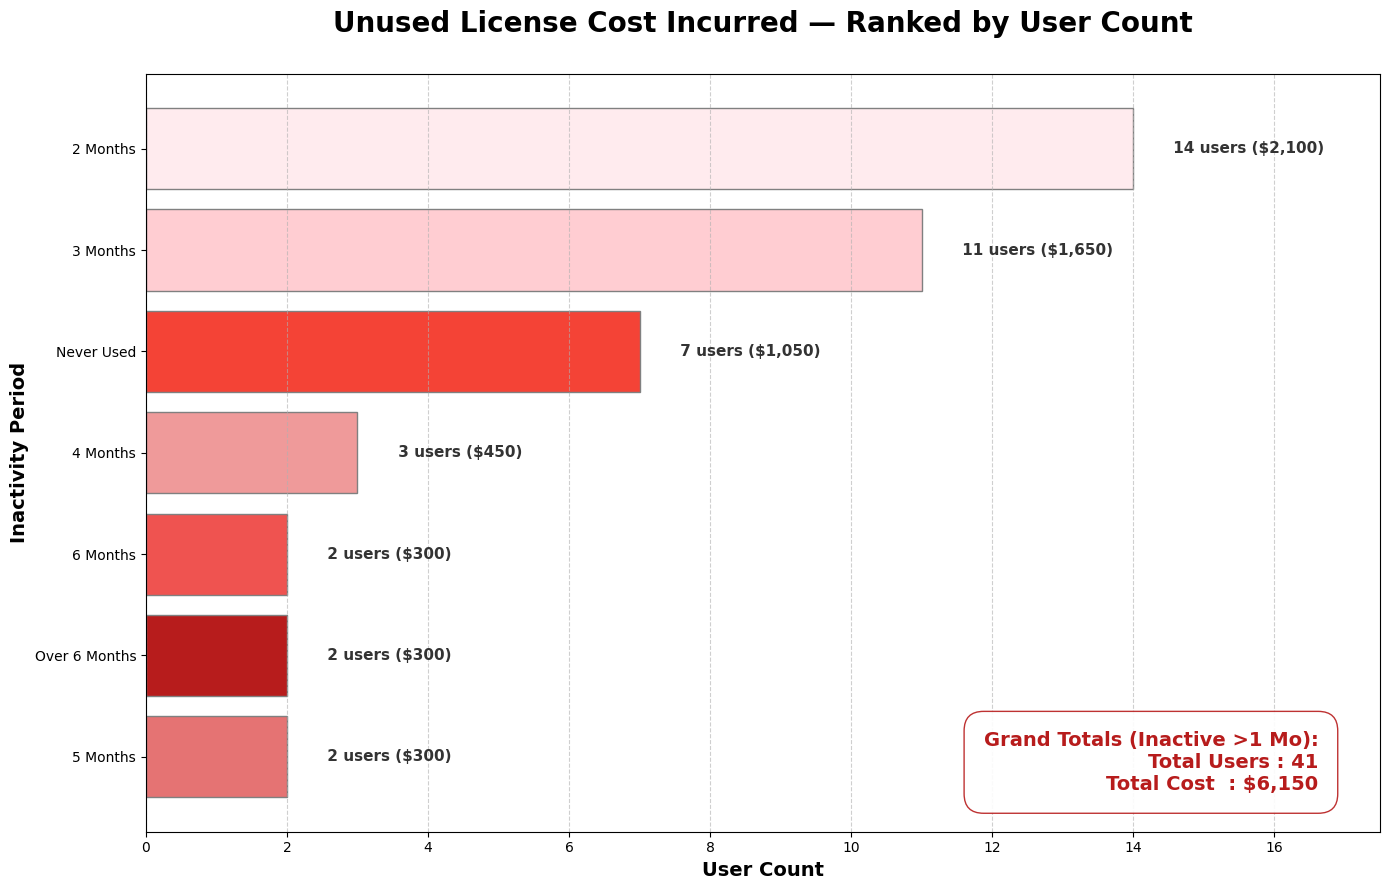


💰 Total inactive users (>1 month): 41
💰 Estimated cost of inactivity    : $6,150


In [24]:
# ============================================================
# Horizontal Bar Chart — Unused License Cost (General Pop)
# Excludes "1 Month" bucket (those are active users)
# ============================================================

# ── Filter out "1 Month" — active users, no savings concern ───
filtered_data = [item for item in raw_data if item['bucket'] != "1 Month"]

# ── Color map — red gradient by severity of inactivity ────────
color_map = {
    '2 Months'     : '#FFEBEE',   # very light red
    '3 Months'     : '#FFCDD2',   # light red
    '4 Months'     : '#EF9A9A',   # medium light red
    '5 Months'     : '#E57373',   # medium red
    '6 Months'     : '#EF5350',   # strong red
    'Never Used'   : '#F44336',   # bright red
    'Over 6 Months': '#B71C1C'    # dark red (worst case)
}

# ── Build chart data with savings value ───────────────────────
# Using worst-case multiplier (6) for savings estimate
chart_data = []
for item in filtered_data:
    bucket   = item['bucket']
    count    = item['user_count']
    save_val = count * 25 * 6    # $25/license × 6 months worst case
    chart_data.append((
        bucket,
        count,
        save_val,
        color_map.get(bucket, '#9E9E9E')  # grey fallback if bucket not in map
    ))

# Sort ascending by user count (highest bar ends up at top in barh)
chart_data.sort(key=lambda x: x[1], reverse=False)

# Unpack sorted values for plotting
sorted_categories = [x[0] for x in chart_data]
sorted_counts     = [x[1] for x in chart_data]
sorted_savings    = [x[2] for x in chart_data]
sorted_colors     = [x[3] for x in chart_data]

# Summary totals for the text box
total_count   = sum(sorted_counts)
total_savings = sum(sorted_savings)

# ── Plot ───────────────────────────────────────────────────────
plt.figure(figsize=(14, 9))

bars = plt.barh(
    sorted_categories,
    sorted_counts,
    color=sorted_colors,
    edgecolor='grey'
)

# Add count + savings label to the right of each bar
for i, (count, save) in enumerate(zip(sorted_counts, sorted_savings)):
    plt.text(
        count + 0.5, i,
        f' {count} users (${save:,})',
        va='center', fontsize=11,
        fontweight='bold', color='#333333'
    )

# Summary box — bottom right
summary_text = (
    f"Grand Totals (Inactive >1 Mo):\n"
    f"Total Users : {total_count}\n"
    f"Total Cost  : ${total_savings:,}"
)
plt.text(
    0.95, 0.05, summary_text,
    transform=plt.gca().transAxes,
    fontsize=14, fontweight='bold', color='#B71C1C',
    bbox=dict(
        facecolor='white', alpha=0.9,
        edgecolor='#B71C1C', boxstyle='round,pad=1'
    ),
    ha='right', va='bottom'
)

# ── Formatting ─────────────────────────────────────────────────
plt.title(
    'Unused License Cost Incurred — Ranked by User Count',
    fontsize=20, fontweight='bold', pad=30
)
plt.xlabel('User Count',       fontsize=14, fontweight='bold')
plt.ylabel('Inactivity Period',fontsize=14, fontweight='bold')

# Dynamic x-axis padding so labels don't get cut off
plt.xlim(0, max(sorted_counts) + (max(sorted_counts) * 0.25))
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('license_usage_general_pop_hbar.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\n💰 Total inactive users (>1 month): {total_count}")
print(f"💰 Estimated cost of inactivity    : ${total_savings:,}")

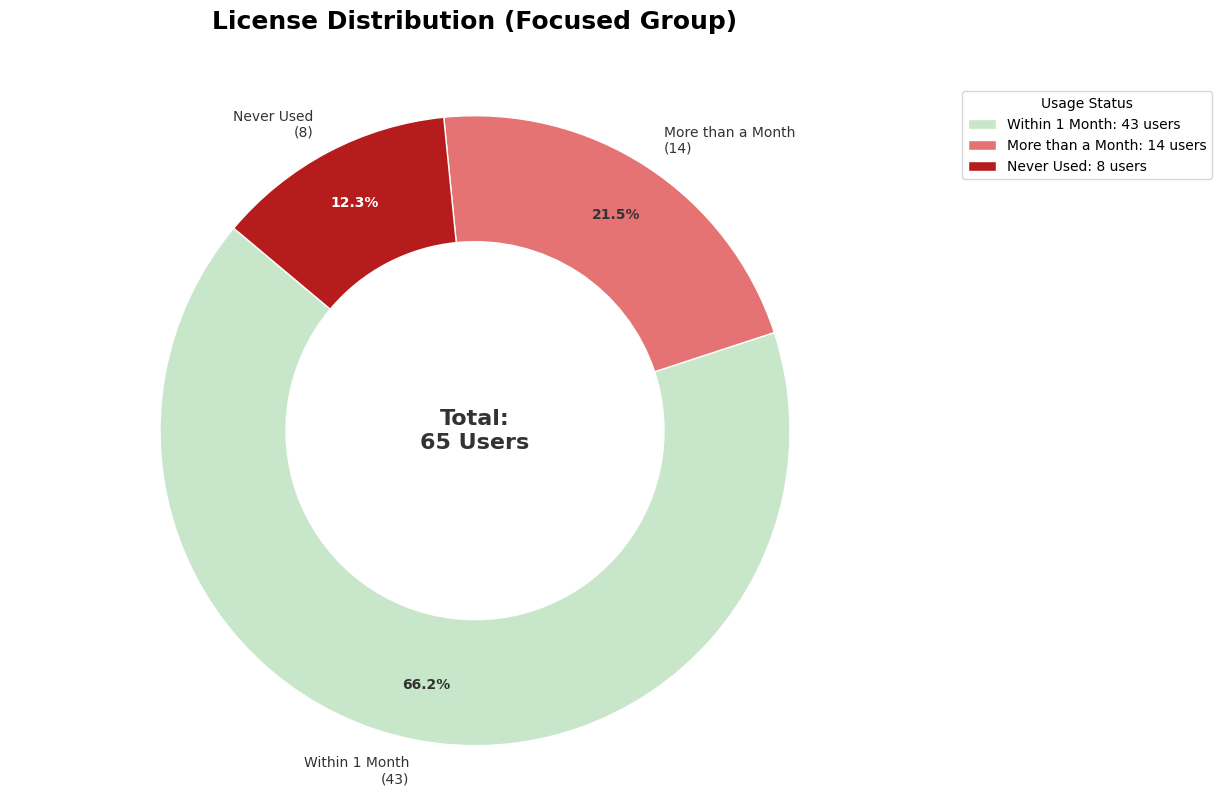

✅ Chart saved: license_distribution_focused_grp.png


In [25]:
# ============================================================
# Chart 4: Focused Group — Usage Distribution (Doughnut)
# LEFT JOIN from tb_gaudit_focused_group → tb_license_assignments
# so users with NO license appear as 'Never Used'
# Converted from SQLite julianday() → BigQuery DATE_DIFF()
# ============================================================
import matplotlib.pyplot as plt

# ── BigQuery version of the focused group usage query ─────────
# LEFT JOIN ensures focused group members with no license = NULL last_used = Never Used
focused_usage_sql = f"""
SELECT
    CASE
        WHEN tla.last_used IS NULL OR tla.last_used = 'N/A'                         THEN 'Never Used'
        WHEN DATE_DIFF(CURRENT_DATE(), SAFE_CAST(tla.last_used AS DATE), DAY) <= 30 THEN 'Within 1 Month'
        ELSE 'More than a Month'
    END AS categories,
    COUNT(*) AS user_count
FROM `{DEV_PID}.{BQ_DATASET}.{BQ_FOCUSED}` tfg
LEFT JOIN `{DEV_PID}.{BQ_DATASET}.{BQ_TABLE}` tla
    ON tfg.email_address = tla.email_address
GROUP BY categories
ORDER BY
    CASE categories
        WHEN 'Within 1 Month'    THEN 1
        WHEN 'More than a Month' THEN 2
        WHEN 'Never Used'        THEN 3
    END
"""

# ── Run query and map results ──────────────────────────────────
rows     = bq_client.query(focused_usage_sql).result()
data_map = {row.categories: row.user_count for row in rows}

# Three fixed categories — default to 0 if missing
categories  = ['Within 1 Month', 'More than a Month', 'Never Used']
user_counts = [
    data_map.get('Within 1 Month', 0),
    data_map.get('More than a Month', 0),
    data_map.get('Never Used', 0)
]
total_users = sum(user_counts)

# ── Colors ────────────────────────────────────────────────────
colors = [
    '#C8E6C9',  # Green     — active
    '#E57373',  # Soft Red  — inactive
    '#B71C1C'   # Dark Red  — never used
]

legend_labels = [f"{cat}: {count} users" for cat, count in zip(categories, user_counts)]
chart_labels  = [f"{cat}\n({count})"     for cat, count in zip(categories, user_counts)]

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))

wedges, texts, autotexts = ax.pie(
    user_counts,
    labels        = chart_labels,
    autopct       = '%1.1f%%',
    startangle    = 140,
    colors        = colors,
    pctdistance   = 0.82,
    labeldistance = 1.1,
    wedgeprops    = {'width': 0.4, 'edgecolor': 'w'}
)

# Text color — white on dark red, black on others
for i, a in enumerate(autotexts):
    a.set_color("white" if i == 2 else "#333333")
    a.set_size(10)
    a.set_weight("bold")
plt.setp(texts, size=10, color="#333333")

# Center label
ax.text(0, 0, f'Total:\n{total_users} Users',
        ha='center', va='center', fontsize=16, fontweight='bold', color='#333333')

ax.legend(wedges, legend_labels, title="Usage Status", loc="upper right", bbox_to_anchor=(1.3, 1))
ax.axis('equal')
plt.title('License Distribution (Focused Group)', pad=40, fontsize=18, fontweight='bold')

plt.savefig('license_distribution_focused_grp.png', bbox_inches='tight', dpi=300)
plt.show()
print("✅ Chart saved: license_distribution_focused_grp.png")

✅ Focused group cost query results:


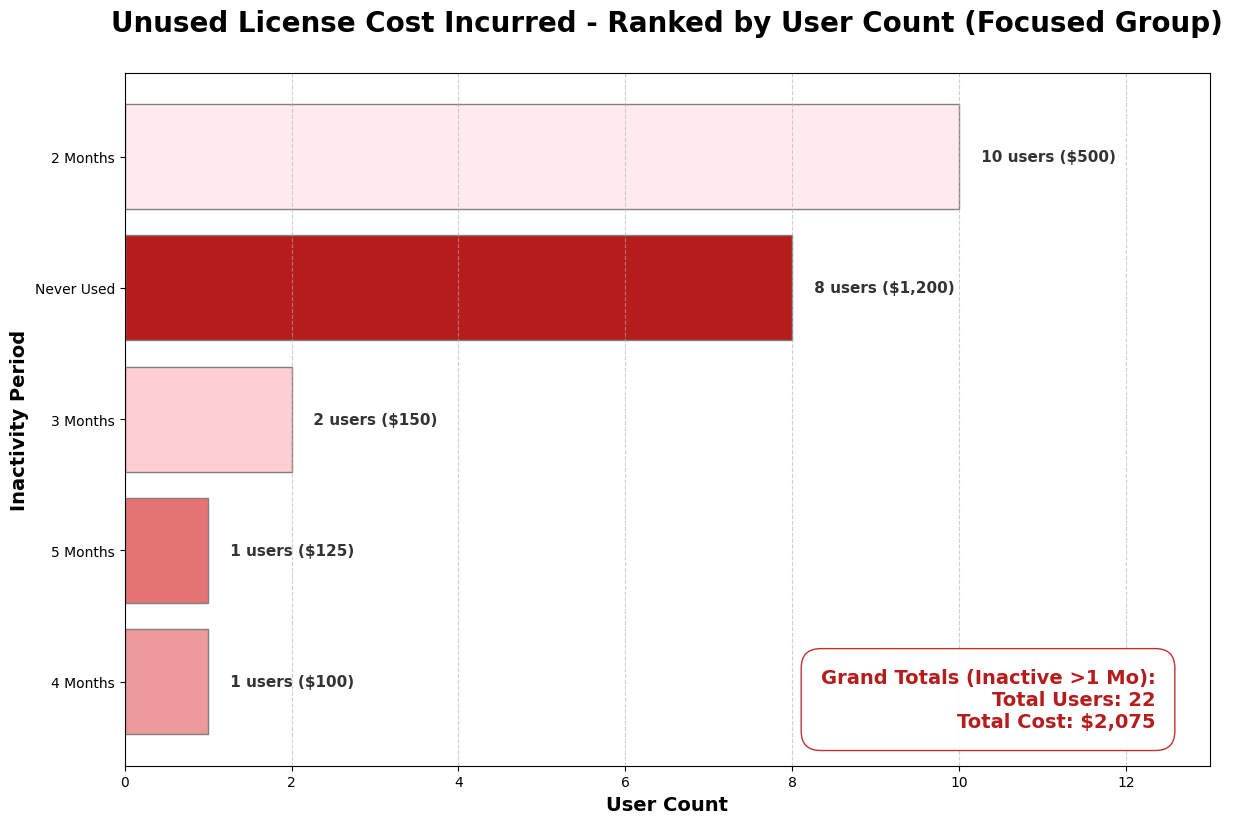

In [26]:
# ============================================================
# Focused Group — Horizontal Bar (Cost by Inactivity)
# Same logic as General Pop H-Bar but scoped to Focused Group
# LEFT JOIN so no-license members appear as 'Never Used'
# ============================================================

# ─────────────────────────────────────────────────────────────
# QUERY 4: Focused Group — detailed buckets for cost chart
# ─────────────────────────────────────────────────────────────
focused_hbar_sql = f"""
    SELECT
        bucket,
        month_multiplier,
        user_count
    FROM (
        SELECT
            CASE
                WHEN tla.last_used IS NULL OR tla.last_used = 'N/A'                                          THEN 'Never Used'
                WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', tla.last_used), DAY) <= 30             THEN '1 Month'
                WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', tla.last_used), DAY) <= 60             THEN '2 Months'
                WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', tla.last_used), DAY) <= 90             THEN '3 Months'
                WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', tla.last_used), DAY) <= 120            THEN '4 Months'
                WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', tla.last_used), DAY) <= 150            THEN '5 Months'
                WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', tla.last_used), DAY) <= 180            THEN '6 Months'
                ELSE 'Over 6 Months'
            END AS bucket,
            CASE
                WHEN tla.last_used IS NULL OR tla.last_used = 'N/A'                                          THEN 6
                WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', tla.last_used), DAY) <= 30             THEN 1
                WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', tla.last_used), DAY) <= 60             THEN 2
                WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', tla.last_used), DAY) <= 90             THEN 3
                WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', tla.last_used), DAY) <= 120            THEN 4
                WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', tla.last_used), DAY) <= 150            THEN 5
                WHEN DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', tla.last_used), DAY) <= 180            THEN 6
                ELSE 6
            END AS month_multiplier,
            COUNT(*) AS user_count
        FROM `{DEV_PID}.{BQ_DATASET}.{BQ_FOCUSED}` tfg
        -- LEFT JOIN keeps focused group members with no license (they show as Never Used)
        LEFT JOIN `{DEV_PID}.{BQ_DATASET}.{BQ_TABLE}` tla
               ON tfg.email_address = tla.email_address
        GROUP BY bucket, month_multiplier
    )
    ORDER BY month_multiplier ASC
"""

# ── Run the query ──────────────────────────────────────────
raw_data = [dict(row) for row in bq_client.query(focused_hbar_sql).result()]
print("✅ Focused group cost query results:")
# Exclude active users (1 Month) from cost chart
filtered_data = [item for item in raw_data if item['bucket'] != '1 Month']

# ── Color map ──────────────────────────────────────────────
color_map = {
    '2 Months'     : '#FFEBEE',
    '3 Months'     : '#FFCDD2',
    '4 Months'     : '#EF9A9A',
    '5 Months'     : '#E57373',
    '6 Months'     : '#EF5350',
    'Over 6 Months': '#F44336',
    'Never Used'   : '#B71C1C'
}

# ── Build chart data ───────────────────────────────────────
chart_data = []
for item in filtered_data:
    bucket     = item['bucket']
    count      = item['user_count']
    multiplier = item['month_multiplier']
    # Cost = $25 per license × months inactive × users
    save_val   = count * 25 * multiplier
    chart_data.append((bucket, count, save_val, color_map.get(bucket, '#9E9E9E')))

# Sort ascending — highest bar at top of horizontal chart
chart_data.sort(key=lambda x: x[1], reverse=False)

sorted_categories = [x[0] for x in chart_data]
sorted_counts     = [x[1] for x in chart_data]
sorted_savings    = [x[2] for x in chart_data]
sorted_colors     = [x[3] for x in chart_data]

total_count   = sum(sorted_counts)
total_savings = sum(sorted_savings)

# ── Plot Horizontal Bar ────────────────────────────────────
plt.figure(figsize=(14, 9))
plt.barh(sorted_categories, sorted_counts,
         color=sorted_colors, edgecolor='grey')

for i, (count, save) in enumerate(zip(sorted_counts, sorted_savings)):
    plt.text(count + 0.2, i,
             f' {count} users (${save:,})',
             va='center', fontsize=11,
             fontweight='bold', color='#333333')

summary_text = (
    f"Grand Totals (Inactive >1 Mo):\n"
    f"Total Users: {total_count}\n"
    f"Total Cost: ${total_savings:,}"
)
plt.text(0.95, 0.05, summary_text,
         transform=plt.gca().transAxes,
         fontsize=14, fontweight='bold', color='#B71C1C',
         bbox=dict(facecolor='white', alpha=0.9,
                   edgecolor='#B71C1C', boxstyle='round,pad=1'),
         ha='right', va='bottom')

plt.title('Unused License Cost Incurred - Ranked by User Count (Focused Group)',
          fontsize=20, fontweight='bold', pad=30)
plt.xlabel('User Count',        fontsize=14, fontweight='bold')
plt.ylabel('Inactivity Period', fontsize=14, fontweight='bold')

if sorted_counts:
    plt.xlim(0, max(sorted_counts) + (max(sorted_counts) * 0.3))

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.savefig('license_audit_focusegrp_hbar.png', bbox_inches='tight', dpi=300)
plt.show()

✅ Connected to PROD → agntspce-agntspace-ai-p-1-18cd


c:\I&I Work Stuff\agent info\extract_user_license\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✅ Aggregated Data:
                 category  query_count  rank_position
0        Code Assistance         72455              1
1        General Inquiry          7424              2
2    General Information          3707              3
3       Equipment Repair          2770              4
4  Documentation Request          2184              5
5    Software Assistance          2058              6
6         Code Assistance         2033              7
7     Salesforce Support          2030              8
8       Software Support          1914              9
9          Data Analysis          1729             10
🔄 Refreshing snapshot table...
✅ Inserted 10 rows
✅ Treemap saved


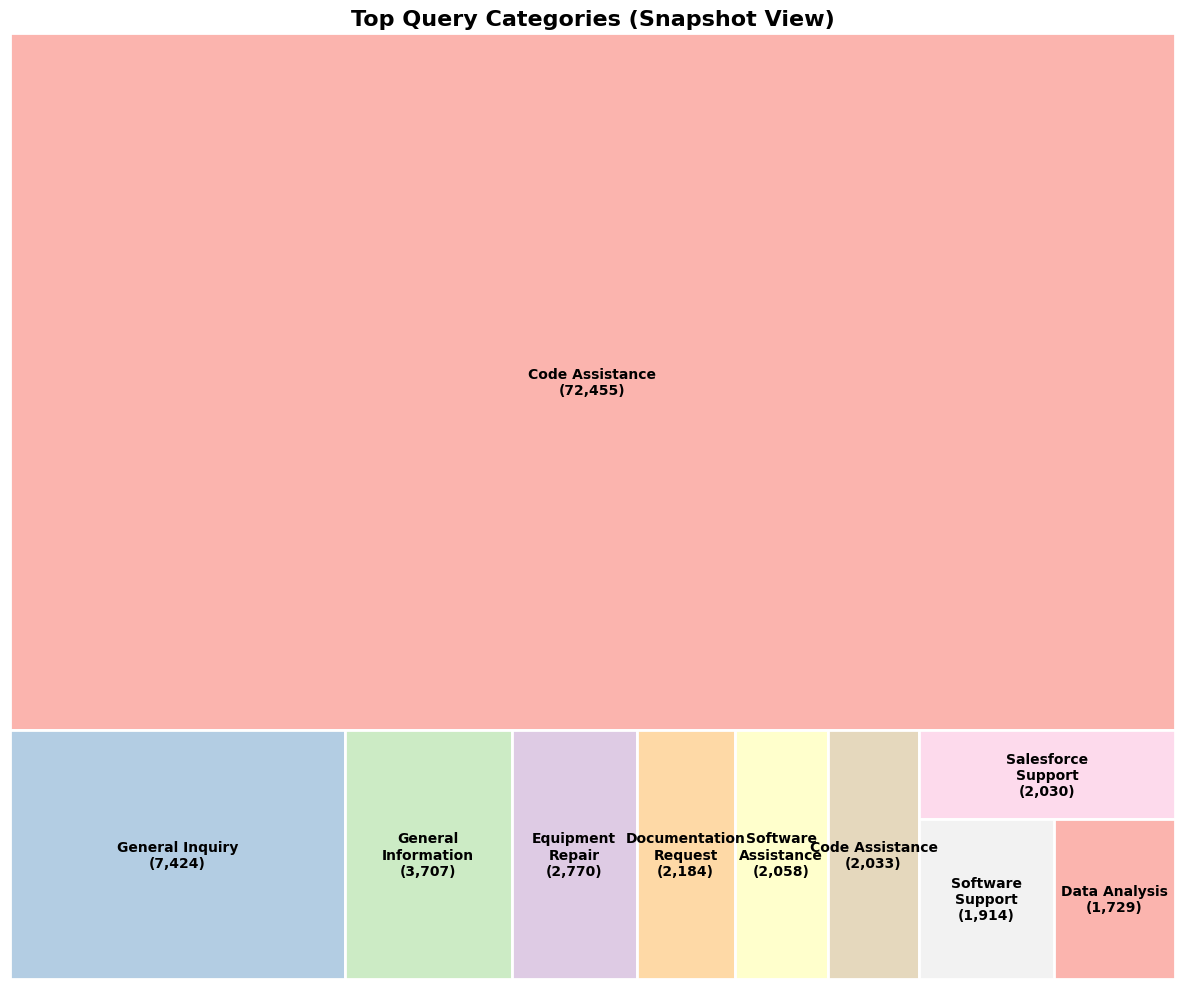

In [27]:
# ============================================================
# FINAL CLEAN VERSION (PRODUCTION SAFE)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import textwrap
from datetime import datetime, timezone
from google.cloud import bigquery
from google.oauth2 import service_account

# ============================================================
# CONFIG
# ============================================================

SOURCE_TABLE = "agntspce-agntspace-ai-p-1-18cd.usage_analytics.direct_classification_report"
TARGET_TABLE = f"{DEV_PID}.{BQ_DATASET}.tb_gaudit_converse_topic"

TOP_N = 10

# ============================================================
# CONNECT
# ============================================================

prod_creds = service_account.Credentials.from_service_account_file(
    PROD_SA,
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

prod_bq_client = bigquery.Client(credentials=prod_creds, project=PROD_PID)

print(f"✅ Connected to PROD → {PROD_PID}")

# ============================================================
# STEP 1: FETCH FULL AGGREGATED DATA (NO DELTA HERE)
# ============================================================

query = f"""
SELECT 
    REGEXP_REPLACE(category, r'\\s+', ' ') AS category,
    COUNT(*) AS query_count
FROM `{SOURCE_TABLE}`
WHERE category IS NOT NULL
GROUP BY category
ORDER BY query_count DESC
LIMIT {TOP_N}
"""

df = prod_bq_client.query(query).to_dataframe()

# Rank
df = df.sort_values(by="query_count", ascending=False).reset_index(drop=True)
df['rank_position'] = df.index + 1

print("✅ Aggregated Data:")
print(df)

# ============================================================
# STEP 2: OVERWRITE SNAPSHOT TABLE (CORRECT DESIGN)
# ============================================================

# 💡 This is NOT wrong — this is snapshot table design

print("🔄 Refreshing snapshot table...")

bq_client.query(f"DELETE FROM `{TARGET_TABLE}` WHERE TRUE").result()

loaded_at = datetime.now(timezone.utc).isoformat()

rows_to_insert = [
    {
        "category": row["category"],
        "query_count": int(row["query_count"]),
        "rank_position": int(row["rank_position"]),
        "loaded_at": loaded_at
    }
    for _, row in df.iterrows()
]

errors = bq_client.insert_rows_json(TARGET_TABLE, rows_to_insert)

if errors:
    print(f"❌ Insert errors: {errors}")
else:
    print(f"✅ Inserted {len(rows_to_insert)} rows")

# ============================================================
# STEP 3: TREEMAP (same as yours)
# ============================================================

def layout_ordered(sizes, x, y, w, h):
    if not sizes:
        return []
    if len(sizes) == 1:
        return [{'x': x, 'y': y, 'w': w, 'h': h}]

    s1 = sizes[0]
    s2 = sum(sizes[1:])
    total = s1 + s2

    res = []

    if w > h:
        w1 = w * s1 / total
        res.extend(layout_ordered([s1], x, y, w1, h))
        res.extend(layout_ordered(sizes[1:], x + w1, y, w - w1, h))
    else:
        h1 = h * s1 / total
        res.extend(layout_ordered([s1], x, y, w, h1))
        res.extend(layout_ordered(sizes[1:], x, y + h1, w, h - h1))

    return res


W, H = 100, 100
rects = layout_ordered(df['query_count'].tolist(), 0, 0, W, H)

fig, ax = plt.subplots(figsize=(12, 10))
cmap = plt.cm.Pastel1

for i, (rect, label, val) in enumerate(zip(rects, df['category'], df['query_count'])):
    color = cmap(i % cmap.N)
    rect_y = H - rect['y'] - rect['h']

    ax.add_patch(patches.Rectangle(
        (rect['x'], rect_y),
        rect['w'], rect['h'],
        facecolor=color,
        edgecolor='white',
        linewidth=2
    ))

    if rect['w'] > 5 and rect['h'] > 5:
        wrapped = textwrap.fill(label, width=15)
        ax.text(
            rect['x'] + rect['w']/2,
            rect_y + rect['h']/2,
            f"{wrapped}\n({val:,})",
            ha='center', va='center',
            fontsize=10, fontweight='bold'
        )

ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.axis('off')

plt.title("Top Query Categories (Snapshot View)", fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig("final_treemap.png", dpi=300)
print("✅ Treemap saved")

plt.show()

In [36]:
# ============================================================
# FINAL: Fetch ALL Agents + Extract FULL Metadata + Load to BQ
# ============================================================

import requests
from typing import List, Dict
from google.oauth2 import service_account
import google.auth.transport.requests
from google.cloud import bigquery
from datetime import datetime
import json

# ── Config ──────────────────────────────────────────────────
AGENT_PROJECT_ID = "855020224673"
AGENT_APP_ID     = "web-search-agentspace-app_1752130827305"
BQ_AGENT_TABLE   = "tb_gaudit_agents"

# ============================================================
# STEP 1: Fetch ALL agents (pagination)
# ============================================================
def fetch_all_agents(project_id, app_id, key_path, location="global") -> List[Dict]:

    scopes = ['https://www.googleapis.com/auth/cloud-platform']
    creds  = service_account.Credentials.from_service_account_file(
        key_path, scopes=scopes
    )
    auth_req = google.auth.transport.requests.Request()

    all_agents = []
    next_page_token = None

    base_url = (
        f"https://{location}-discoveryengine.googleapis.com/v1alpha/"
        f"projects/{project_id}/locations/{location}/collections/default_collection/"
        f"engines/{app_id}/assistants/default_assistant/agents"
    )

    print("🔄 Fetching all agents...")

    while True:
        creds.refresh(auth_req)
        headers = {"Authorization": f"Bearer {creds.token}"}

        params = {"pageSize": 100}
        if next_page_token:
            params["pageToken"] = next_page_token

        response = requests.get(base_url, headers=headers, params=params)
        response.raise_for_status()
        data = response.json()

        page_agents = data.get('agents', [])
        all_agents.extend(page_agents)

        print(f"   → {len(page_agents)} fetched | Total: {len(all_agents)}")

        next_page_token = data.get('nextPageToken')
        if not next_page_token:
            break

    print(f"✅ Total agents fetched: {len(all_agents)}")
    return all_agents


# ============================================================
# STEP 2: Save FULL metadata to BigQuery
# ============================================================
def save_agents_to_bq(agents: List[Dict]):

    if not agents:
        print("⚠️ No agents to save.")
        return

    full_table_id = f"{DEV_PID}.{BQ_DATASET}.{BQ_AGENT_TABLE}"

    rows_to_insert = []

    for agent in agents:
        agent_id = agent.get("name", "").split("/")[-1]

        # Extract model safely (nested JSON)
        model = None
        try:
            model = agent.get("lowCodeAgentDefinition", {}) \
                         .get("nodes", [])[0] \
                         .get("llmAgentNode", {}) \
                         .get("model", None)
        except:
            model = None

        rows_to_insert.append({
            "agent_id"   : agent_id,
            "agent_name" : agent.get("displayName", "Unknown"),
            "description": agent.get("description", None),
            "state"      : agent.get("state", None),
            "create_time": agent.get("createTime", None),
            "update_time": agent.get("updateTime", None),
            "model"      : model,
            "raw_json"   : json.dumps(agent),   # 🔥 full payload stored
            "loaded_at"  : datetime.utcnow().isoformat()
        })

    print(f"\n⬆️ Loading {len(rows_to_insert)} records into {full_table_id}...")

    # ============================================================
    # WRITE_TRUNCATE (safe, no streaming issues)
    # ============================================================
    job_config = bigquery.LoadJobConfig(
        schema=[
            bigquery.SchemaField("agent_id", "STRING"),
            bigquery.SchemaField("agent_name", "STRING"),
            bigquery.SchemaField("description", "STRING"),
            bigquery.SchemaField("state", "STRING"),
            bigquery.SchemaField("create_time", "TIMESTAMP"),
            bigquery.SchemaField("update_time", "TIMESTAMP"),
            bigquery.SchemaField("model", "STRING"),
            bigquery.SchemaField("raw_json", "STRING"),
            bigquery.SchemaField("loaded_at", "TIMESTAMP"),
        ],
        write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
    )

    job = bq_client.load_table_from_json(
        rows_to_insert,
        full_table_id,
        job_config=job_config
    )

    job.result()

    if job.errors:
        print(f"❌ Load errors: {job.errors}")
    else:
        print(f"✅ Successfully loaded {len(rows_to_insert)} agents into {full_table_id}")


# ============================================================
# MAIN RUN
# ============================================================
agents = fetch_all_agents(
    project_id = AGENT_PROJECT_ID,
    app_id     = AGENT_APP_ID,
    key_path   = PROD_SA
)

if agents:
    save_agents_to_bq(agents)
else:
    print("⚠️ No agents fetched.")

🔄 Fetching all agents...
   → 100 fetched | Total: 100
   → 100 fetched | Total: 200
   → 100 fetched | Total: 300
   → 100 fetched | Total: 400
   → 100 fetched | Total: 500
   → 100 fetched | Total: 600
   → 100 fetched | Total: 700
   → 100 fetched | Total: 800
   → 99 fetched | Total: 899
✅ Total agents fetched: 899

⬆️ Loading 899 records into agntspce-agntspace-ai-d-1-eced.gemini_exports.tb_gaudit_agents...


C:\Users\240155546\AppData\Local\Temp\ipykernel_22756\1587904864.py:100: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "loaded_at"  : datetime.utcnow().isoformat()


✅ Successfully loaded 899 agents into agntspce-agntspace-ai-d-1-eced.gemini_exports.tb_gaudit_agents


In [ ]:
# # Creates a view for user management master data
# # creates a final combined view of users, groups, and license status
# DROP VIEW IF EXISTS v_user_management_master;

# CREATE VIEW v_user_management_master AS
# WITH combined_population AS (
#     -- Step 1: Identity Logic (Unique emails & Groups)
#     SELECT email_address, 'Focused Group' AS group_indicator
#     FROM tb_focused_group
#     UNION
#     SELECT email_address, 'General Population' AS group_indicator
#     FROM tb_license_assignments
#     WHERE email_address NOT IN (SELECT email_address FROM tb_focused_group)
# ),
# data_prep AS (
#     -- Step 2: Attribute Logic (Joining dates and creating claim_status)
#     SELECT 
#         p.email_address,
#         p.group_indicator,
#         a.date_assigned,
#         a.last_used,
#         CASE 
#             WHEN a.date_assigned IS NOT NULL THEN 1 
#             ELSE 0 
#         END AS claim_status
#     FROM combined_population p
#     LEFT JOIN tb_license_assignments a ON p.email_address = a.email_address
# )
# -- Step 3: Combine real data with your static "Reserved" and "Balance" rows
# SELECT 
#     email_address, 
#     group_indicator, 
#     date_assigned, 
#     last_used, 
#     claim_status 
# FROM data_prep
# UNION ALL
# SELECT "Reserved", "Development", "2026-01-01", "2026-01-01", 50
# UNION ALL
# SELECT "Balance", "Available", "2026-01-01", "2026-01-01", 23;


In [ ]:
# from google.cloud import bigquery
# from google.oauth2 import service_account
# import sqlite3, pandas as pd, os

# # Load dev credentials
# dev_creds = service_account.Credentials.from_service_account_file(
#     r"C:\I&I Work Stuff\Agentspace_Dev.json",
#     scopes=["https://www.googleapis.com/auth/cloud-platform"]
# )
# dev_client = bigquery.Client(credentials=dev_creds, project="agntspce-agntspace-ai-d-1-eced")

# # Read from SQLite
# conn = sqlite3.connect(r"C:\\I&I Work Stuff\\agent info\\Audit\\audit_results.db")
# df = pd.read_sql("SELECT * FROM tb_license_assignments", conn)
# conn.close()

# # Push to BigQuery (WRITE_TRUNCATE = replace existing data)
# job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
# job = dev_client.load_table_from_dataframe(
#     df, 
#     "agntspce-agntspace-ai-d-1-eced.gemini_exports.tb_license_assignments",
#     job_config=job_config
# )
# job.result()
# print("✅ Data pushed to BigQuery!")

✅ Data pushed to BigQuery!


In [102]:
# ============================================================
# AGENT AUDIT — Fetch ALL agents from Discovery Engine API
#               and write full details directly to BigQuery
# ============================================================
# Logic:
#   - Paginates through API (100 per page) using PROD credentials
#   - Extracts: agent_id, name, description, state, model,
#               connector info, create/update timestamps
#   - has_connector = True if lowCodeAgentDefinition has connectorSpecs
#   - Clears old data from tb_gaudit_agents before fresh insert
#   - Writes to DEV BigQuery using bq_client (already initialized)
#
# BQ Table : gemini_exports.tb_gaudit_agents
# PROD creds → API call  |  DEV creds → BQ write
# ============================================================

import requests
import json
from datetime import datetime, timezone
from typing import List, Dict, Optional
from google.oauth2 import service_account
import google.auth.transport.requests

# ── Config ──────────────────────────────────────────────────
# PROD project number (numeric ID, not the string project name)
AGENT_PROJECT_ID = "855020224673"
AGENT_APP_ID     = "web-search-agentspace-app_1752130827305"
BQ_AGENT_TABLE   = "tb_gaudit_agents"   # target table in gemini_exports


# ─────────────────────────────────────────────────────────────
# STEP 1: Fetch ALL agents with pagination
# Uses PROD service account — agents live in PROD project
# Loops until nextPageToken is empty (100 agents per page)
# ─────────────────────────────────────────────────────────────
def fetch_all_agents(
    project_id : str,
    app_id     : str,
    key_path   : str,
    location   : str = "global"
) -> List[Dict]:

    # Load PROD service account credentials for API access
    scopes = ['https://www.googleapis.com/auth/cloud-platform']
    creds  = service_account.Credentials.from_service_account_file(
        key_path, scopes=scopes
    )
    auth_req = google.auth.transport.requests.Request()

    all_agents      = []
    next_page_token = None

    # Base endpoint for agents list
    base_url = (
        f"https://{location}-discoveryengine.googleapis.com/v1alpha/"
        f"projects/{project_id}/locations/{location}/collections/default_collection/"
        f"engines/{app_id}/assistants/default_assistant/agents"
    )

    print("🔄 Fetching agents from Discovery Engine API (paginated)...")

    while True:
        # Refresh token each loop — prevents expiry on large datasets
        creds.refresh(auth_req)
        headers = {"Authorization": f"Bearer {creds.token}"}

        # 100 agents per page, pass token if continuing from previous page
        params = {"pageSize": 100}
        if next_page_token:
            params["pageToken"] = next_page_token

        response = requests.get(base_url, headers=headers, params=params)
        response.raise_for_status()
        data = response.json()

        page_agents = data.get('agents', [])
        all_agents.extend(page_agents)
        print(f"   → Page fetched: {len(page_agents)} agents | Total: {len(all_agents)}")

        # If no nextPageToken → we've hit the last page
        next_page_token = data.get('nextPageToken')
        if not next_page_token:
            break

    print(f"✅ Total agents fetched: {len(all_agents)}")
    return all_agents


# ─────────────────────────────────────────────────────────────
# STEP 2: Helper — extract connector info from agent definition
# lowCodeAgentDefinition → nodes → llmAgentNode → selectedTools
# If connectorSpecs exists inside selectedTools → has a connector
# ─────────────────────────────────────────────────────────────
def extract_connector_info(agent: Dict):
    """
    Digs into lowCodeAgentDefinition to find connector details.
    Returns (has_connector: bool, connector_name: str or None)

    Structure we're navigating:
    lowCodeAgentDefinition
      └── nodes[]
            └── llmAgentNode
                  └── selectedTools
                        └── connectorSpecs[]
                              └── connector (resource path)
                                  displayName
    """
    try:
        nodes = (
            agent
            .get('lowCodeAgentDefinition', {})
            .get('nodes', [])
        )
        for node in nodes:
            llm_node = node.get('llmAgentNode', {})
            connector_specs = (
                llm_node
                .get('selectedTools', {})
                .get('connectorSpecs', [])
            )
            if connector_specs:
                # Take first connector's display name if available
                connector_name = connector_specs[0].get('displayName', None)
                # Fallback: parse connector resource path for name
                if not connector_name:
                    connector_path = connector_specs[0].get('connector', '')
                    connector_name = connector_path.split('/')[-1] if connector_path else None
                return True, connector_name
    except Exception:
        pass  # if structure is unexpected, treat as no connector

    return False, None


# ─────────────────────────────────────────────────────────────
# STEP 3: Helper — extract Gemini model name from agent definition
# lowCodeAgentDefinition → nodes → llmAgentNode → model
# ─────────────────────────────────────────────────────────────
def extract_model(agent: Dict) -> Optional[str]:
    """
    Extracts the Gemini model name used by this agent.
    Example: 'gemini-2.5-flash'
    Returns None if not found.
    """
    try:
        nodes = (
            agent
            .get('lowCodeAgentDefinition', {})
            .get('nodes', [])
        )
        for node in nodes:
            model = node.get('llmAgentNode', {}).get('model')
            if model:
                return model
    except Exception:
        pass
    return None


# ─────────────────────────────────────────────────────────────
# STEP 4: Save all agents directly to BigQuery
# Clears old data first (DELETE WHERE TRUE)
# Then inserts fresh rows with full agent details
# ─────────────────────────────────────────────────────────────
def save_agents_to_bq(agents: List[Dict]):
    """
    Processes raw agent API response and writes to tb_gaudit_agents.

    Columns written:
      agent_id       → last segment of resource name  e.g. '10005859...'
      agent_name     → displayName
      description    → agent description / purpose
      state          → PRIVATE / PUBLIC
      model_used     → Gemini model name
      has_connector  → True if agent uses a connector
      connector_name → name of connector (or None)
      create_time    → ISO timestamp when agent was created
      update_time    → ISO timestamp of last update
      loaded_at      → current UTC time (when we ran this script)
    """
    if not agents:
        print("⚠️  No agents to save.")
        return

    full_table_id = f"{DEV_PID}.{BQ_DATASET}.{BQ_AGENT_TABLE}"
    now_utc       = datetime.now(timezone.utc).isoformat()  # snapshot timestamp

    # ── Clear old records before inserting fresh batch ────────
    # Same DELETE pattern used in tb_license_assignments
    print(f"\n🔄 Clearing old records from {full_table_id}...")
    bq_client.query(f"DELETE FROM `{full_table_id}` WHERE TRUE").result()
    print(f"   → Old records cleared")

    # ── Build rows from API response ──────────────────────────
    rows_to_insert = []
    for agent in agents:

        # agent_id → last part of the full resource path
        # e.g. 'projects/.../agents/10005859170023523369' → '10005859170023523369'
        agent_id   = agent.get("name", "").split("/")[-1]
        agent_name = agent.get("displayName", "Unknown")
        description= agent.get("description", None)
        state      = agent.get("state", None)           # PRIVATE / PUBLIC
        create_time= agent.get("createTime", None)      # ISO timestamp string
        update_time= agent.get("updateTime", None)      # ISO timestamp string

        # Extract model and connector from nested definition
        model_used                  = extract_model(agent)
        has_connector, connector_name = extract_connector_info(agent)

        rows_to_insert.append({
            "agent_id"      : agent_id,
            "agent_name"    : agent_name,
            "description"   : description,
            "state"         : state,
            "model_used"    : model_used,
            "has_connector" : has_connector,   # BOOL
            "connector_name": connector_name,  # STRING or None → NULL in BQ
            "create_time"   : create_time,     # TIMESTAMP string
            "update_time"   : update_time,     # TIMESTAMP string
            "loaded_at"     : now_utc          # when this script ran
        })

    # ── Insert fresh rows into BigQuery ───────────────────────
    errors = bq_client.insert_rows_json(full_table_id, rows_to_insert)
    if errors:
        print(f"❌ BigQuery insert errors: {errors}")
    else:
        print(f"✅ Inserted {len(rows_to_insert)} agents into {full_table_id}")

    # ── Quick preview of what was saved ───────────────────────
    print(f"\n📋 Sample of agents saved:")
    for r in rows_to_insert[:5]:
        print(f"   ID: {r['agent_id']}")
        print(f"   Name: {r['agent_name']}")
        print(f"   Model: {r['model_used']} | State: {r['state']} | Connector: {r['has_connector']} ({r['connector_name']})")
        print(f"   {'─'*50}")


# ─────────────────────────────────────────────────────────────
# MAIN — Run: Fetch → Save
# PROD_SA already loaded from main audit cell (Step 0)
# bq_client already initialized from main audit cell (Step 0)
# ─────────────────────────────────────────────────────────────
agents = fetch_all_agents(
    project_id = AGENT_PROJECT_ID,
    app_id     = AGENT_APP_ID,
    key_path   = PROD_SA    # PROD service account → API access
)

if agents:
    save_agents_to_bq(agents)
else:
    print("⚠️  No agents returned from API.")

🔄 Fetching agents from Discovery Engine API (paginated)...
   → Page fetched: 100 agents | Total: 100
   → Page fetched: 100 agents | Total: 200
   → Page fetched: 100 agents | Total: 300
   → Page fetched: 100 agents | Total: 400
   → Page fetched: 100 agents | Total: 500
   → Page fetched: 100 agents | Total: 600
   → Page fetched: 100 agents | Total: 700
   → Page fetched: 100 agents | Total: 800
   → Page fetched: 90 agents | Total: 890
✅ Total agents fetched: 890

🔄 Clearing old records from agntspce-agntspace-ai-d-1-eced.gemini_exports.tb_gaudit_agents...
   → Old records cleared
✅ Inserted 890 agents into agntspce-agntspace-ai-d-1-eced.gemini_exports.tb_gaudit_agents

📋 Sample of agents saved:
   ID: 10005859170023523369
   Name: Paymode PDF to CSV
   Model: gemini-2.5-pro | State: PRIVATE | Connector: False (None)
   ──────────────────────────────────────────────────
   ID: 10012390695619430915
   Name: Generate Meeting Agenda
   Model: gemini-2.5-pro | State: PRIVATE | Connect

In [2]:
# ============================================================
# PROMPT CLASSIFICATION — Full Historical Run
# ============================================================
# What this does:
#   - Reads user queries from usage_audit table (PROD project)
#   - Masks PII (emails → [EMAIL], digits → X)
#   - Uses Gemini 2.0 Flash via BigQuery AI.GENERATE to classify
#     each query into a help desk category
#   - Stores results in direct_classification_report (PROD project)
#
# Connection:
#   - Runs on PROD BQ client (usage_analytics dataset is in PROD)
#   - Uses a pre-configured BQ remote connection to call Gemini
#
# When to run:
#   - Run ONCE for historical backfill (last 200 days)
#   - After that, use the INCREMENTAL version below
# ============================================================

from google.cloud import bigquery
from google.oauth2 import service_account
from dotenv import load_dotenv
import os

# ── Load PROD credentials (usage_analytics is in PROD project) ──
# We need PROD client here because source + destination tables
# are both in the PROD project (agntspce-agntspace-ai-p-1-18cd)
load_dotenv(r'C:\I&I Work Stuff\agent info\agentspace_env_p.txt', override=True)
PROD_SA  = os.getenv("SERVICE_ACCOUNT")
PROD_PID = os.getenv("PROJECT_ID")

prod_creds = service_account.Credentials.from_service_account_file(
    PROD_SA,
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)
# PROD BQ client — needed to access usage_analytics dataset
prod_bq_client = bigquery.Client(credentials=prod_creds, project=PROD_PID)
print(f"✅ PROD BQ Client ready → {PROD_PID}")


def run_full_classification():
    """
    Full historical classification — CREATE OR REPLACE.
    Processes all queries from the last 200 days.
    WARNING: This overwrites the entire report table.
    Only run this for initial backfill or full refresh.
    """
    print("\n🔄 Running Gemini AI classification on user queries...")
    print("   ⚠️  This may take several minutes depending on row count...")

    # ── The classification query ──────────────────────────────
    # Uses BigQuery's AI.GENERATE function with Gemini 2.0 Flash
    # model_params uses JSON'' syntax (single quotes) — avoids
    # Python triple-quote conflicts
    classification_sql = """
    CREATE OR REPLACE TABLE `agntspce-agntspace-ai-p-1-18cd.usage_analytics.direct_classification_report` AS
    SELECT
        GENERATE_UUID() AS rowid,

        -- Mask PII before storing: digits → X, emails → [EMAIL]
        REGEXP_REPLACE(
            REGEXP_REPLACE(userQuery, r'\\d', 'X'),
            r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\\.[a-zA-Z]{2,}',
            '[EMAIL]'
        ) AS userQuery,

        -- Gemini classifies the masked query into a help desk category
        -- COALESCE handles cases where AI returns NULL (safety block or error)
        COALESCE(
            AI.GENERATE(
                CONCAT(
                    'You are a Help Desk Classifier. Classify the user query into a category.\\n',
                    'Rules:\\n',
                    '1. Label based on what the user is asking (e.g. "Payroll Support", "Code Assistance").\\n',
                    '2. Ignore masked PII like XXX or [EMAIL].\\n',
                    '3. Return ONLY the category name, nothing else.\\n\\n',
                    'User Request: ',
                    REGEXP_REPLACE(
                        REGEXP_REPLACE(userQuery, r'\\d', 'X'),
                        r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\\.[a-zA-Z]{2,}',
                        '[EMAIL]'
                    )
                ),
                connection_id => 'projects/agntspce-agntspace-ai-p-1-18cd/locations/us/connections/audit',
                endpoint => 'gemini-2.0-flash',
                model_params => JSON'{"generationConfig": {"temperature": 0.0, "maxOutputTokens": 20}}'
            ).result,
            'Unclassified (Safety/Error)'
        ) AS category

    FROM `agntspce-agntspace-ai-p-1-18cd.usage_analytics.usage_audit`
    WHERE
        userQuery IS NOT NULL
        AND TRIM(userQuery) != ''
        AND DATE(timestamp) >= CURRENT_DATE() - 200;  -- last 200 days
    """

    try:
        # Run using PROD client — source table is in PROD project
        job = prod_bq_client.query(classification_sql)
        job.result()  # wait for completion
        print("✅ Full classification complete!")
        print("   Results stored in: agntspce-agntspace-ai-p-1-18cd.usage_analytics.direct_classification_report")
    except Exception as e:
        print(f"❌ Classification job failed: {e}")
        print("\n   Check BigQuery job logs for details.")
        raise  # show full traceback in Jupyter


# Run it
run_full_classification()

✅ PROD BQ Client ready → agntspce-agntspace-ai-p-1-18cd

🔄 Running Gemini AI classification on user queries...
   ⚠️  This may take several minutes depending on row count...
❌ Classification job failed: 403 Access Denied: Connection projects/agntspce-agntspace-ai-p-1-18cd/locations/us/connections/audit: User does not have bigquery.connections.use permission for connection projects/agntspce-agntspace-ai-p-1-18cd/locations/us/connections/audit.; reason: accessDenied, message: Access Denied: Connection projects/agntspce-agntspace-ai-p-1-18cd/locations/us/connections/audit: User does not have bigquery.connections.use permission for connection projects/agntspce-agntspace-ai-p-1-18cd/locations/us/connections/audit.

Location: US
Job ID: e1943638-9a81-4ad3-9e70-7749ffa96a82


   Check BigQuery job logs for details.


Forbidden: 403 Access Denied: Connection projects/agntspce-agntspace-ai-p-1-18cd/locations/us/connections/audit: User does not have bigquery.connections.use permission for connection projects/agntspce-agntspace-ai-p-1-18cd/locations/us/connections/audit.; reason: accessDenied, message: Access Denied: Connection projects/agntspce-agntspace-ai-p-1-18cd/locations/us/connections/audit: User does not have bigquery.connections.use permission for connection projects/agntspce-agntspace-ai-p-1-18cd/locations/us/connections/audit.

Location: US
Job ID: e1943638-9a81-4ad3-9e70-7749ffa96a82


In [ ]:
# #“This query uses Gemini AI to classify user queries into meaningful categories after masking sensitive data, and stores the results in BigQuery for analysis.”
# #----------------------------- PROMPT CLASSIFICATION ----------------------------------------------
# CREATE OR REPLACE TABLE `agntspce-agntspace-ai-p-1-18cd.usage_analytics.direct_classification_report` AS
# SELECT
#   GENERATE_UUID() AS rowid,
#   REGEXP_REPLACE(
#     REGEXP_REPLACE(userQuery, r'\d', 'X'), 
#     r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', 
#     '[EMAIL]'
#   ) AS userQuery,

#   COALESCE(
#     AI.GENERATE(
#       CONCAT(
#         'You are a Help Desk Classifier. Create a category classification based on the intent of the user query.\n',
#         'Rules:\n',
#         '1. Label based on what the user is asking for (examples: "Payroll Support", "Equipment Repair", "Code Assistance").\n',
#         '2. Ignore masked PII (XXX, [EMAIL]).\n',
#         '3. Return ONLY the category name.\n\n',
#         'User Request: ', 
#         REGEXP_REPLACE(
#           REGEXP_REPLACE(userQuery, r'\d', 'X'), 
#           r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', 
#           '[EMAIL]'
#         )
#       ),
#       connection_id => 'projects/agntspce-agntspace-ai-p-1-18cd/locations/us/connections/audit',
#       endpoint => 'gemini-2.0-flash', 
#       model_params => JSON """
#         {
#           "generationConfig": {
#             "temperature": 0.0, 
#             "maxOutputTokens": 20
#           },
#           "safetySettings": [
#             {"category": "HARM_CATEGORY_HATE_SPEECH", "threshold": "BLOCK_ONLY_HIGH"},
#             {"category": "HARM_CATEGORY_DANGEROUS_CONTENT", "threshold": "BLOCK_ONLY_HIGH"},
#             {"category": "HARM_CATEGORY_SEXUALLY_EXPLICIT", "threshold": "BLOCK_ONLY_HIGH"},
#             {"category": "HARM_CATEGORY_HARASSMENT", "threshold": "BLOCK_ONLY_HIGH"}
#           ]
#         }
#       """
#     ).result,
#     'Unclassified (Safety/Error)'
#   ) AS category
# FROM
#   `agntspce-agntspace-ai-p-1-18cd.usage_analytics.usage_audit`
# WHERE
#   userQuery IS NOT NULL 
#   AND TRIM(userQuery) != ''
#   AND DATE(timestamp) >= CURRENT_DATE()-200;

In [ ]:
# # Note: The above query creates a new table with classifications for all historical data. For incremental updates, we can modify the WHERE clause to only include new records that haven't been classified yet.
# # INCREMENTAL
# INSERT INTO `agntspce-agntspace-ai-p-1-18cd.usage_analytics.direct_classification_report`
# SELECT
#   GENERATE_UUID() AS rowid,
#   -- We pre-calculate the masked query to use it in both the prompt and the final column
#   masked_query AS userQuery,
#   COALESCE(
#     AI.GENERATE(
#       CONCAT(
#         'You are a Help Desk Classifier. Create a category classification based on the intent of the user query.\n',
#         'Rules:\n',
#         '1. Label based on what the user is asking for (examples: "Payroll Support", "Equipment Repair", "Code Assistance").\n',
#         '2. Ignore masked PII (XXX, [EMAIL]).\n',
#         '3. Return ONLY the category name.\n\n',
#         'User Request: ', 
#         masked_query
#       ),
#       connection_id => 'projects/agntspce-agntspace-ai-p-1-18cd/locations/us/connections/audit',
#       endpoint => 'gemini-2.0-flash', 
#       model_params => JSON """
#         {
#           "generationConfig": {
#             "temperature": 0.0, 
#             "maxOutputTokens": 20
#           }
#         }
#       """
#     ).result,
#     'Unclassified (Safety/Error)'
#   ) AS category
# FROM (
#   -- Inner subquery to handle PII masking and filter for new records only
#   SELECT 
#     userQuery AS raw_query,
#     REGEXP_REPLACE(
#       REGEXP_REPLACE(userQuery, r'\d', 'X'), 
#       r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', 
#       '[EMAIL]'
#     ) AS masked_query,
#     timestamp
#   FROM
#     `agntspce-agntspace-ai-p-1-18cd.usage_analytics.usage_audit` AS src
#   WHERE
#     userQuery IS NOT NULL 
#     AND TRIM(userQuery) != ''
#     AND DATE(timestamp) between CURRENT_DATE()-7 and CURRENT_DATE()-1
#     -- INCREMENTAL LOGIC: Only pull queries that don't exist in the report table yet
#     AND NOT EXISTS (
#       SELECT 1 
#       FROM `agntspce-agntspace-ai-p-1-18cd.usage_analytics.direct_classification_report` AS dest
#       -- Note: Matching on the masked query to avoid re-processing identical intents
#       WHERE dest.userQuery = REGEXP_REPLACE(
#                                REGEXP_REPLACE(src.userQuery, r'\d', 'X'), 
#                                r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', 
#                                '[EMAIL]'
#                              )
#     )
# ) AS base_data;

In [ ]:
# # Metrics Generation

#   select TRIM(category, '\n') AS category,count(*) as `Count` from `agntspce-agntspace-ai-p-1-18cd.usage_analytics.direct_classification_report` group by category
#   order by count(*) desc limit 10

In [ ]:
# # ============================================================
# # TREEMAP — Top 10 Query Categories from Gemini Classification
# # ============================================================
# # Reads from: agntspce-agntspace-ai-p-1-18cd.usage_analytics.direct_classification_report
# # Uses PROD credentials (read-only) — this table lives in PROD project
# # Draws a treemap showing which query categories are most common
# # ============================================================
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# import pandas as pd
# import textwrap
# from google.cloud import bigquery
# from google.oauth2 import service_account
# # ── Use PROD credentials to read from PROD project ──────────
# # PROD_SA and PROD_PID are already loaded in Step 0 (Cell 1)
# # We create a separate PROD BQ client here for reading only
# prod_creds = service_account.Credentials.from_service_account_file(
#     PROD_SA,
#     scopes=["https://www.googleapis.com/auth/cloud-platform"]
# )
# prod_bq_client = bigquery.Client(credentials=prod_creds, project=PROD_PID)
# print(f"✅ PROD BQ Client ready → project: {PROD_PID}")
# # ── Query: top 10 categories from classification report ─────
# # Counts how many queries fall into each AI-classified category
# query = """
#     SELECT 
#         category,
#         COUNT(*) AS Count
#     FROM `agntspce-agntspace-ai-p-1-18cd.usage_analytics.direct_classification_report`
#     WHERE category IS NOT NULL
#     GROUP BY category
#     ORDER BY Count DESC
#     LIMIT 10
# """
# # Fetch results into a pandas DataFrame
# df = prod_bq_client.query(query).to_dataframe()
# # Sort descending so largest block comes first in treemap
# df = df.sort_values(by="Count", ascending=False).reset_index(drop=True)
# print(f"✅ Fetched {len(df)} categories from BigQuery")
# print(df.to_string(index=False))
# # ── Treemap layout function ──────────────────────────────────
# # Recursively splits the canvas (W x H) proportionally by size
# # Alternates between horizontal and vertical splits based on aspect ratio
# def layout_ordered(sizes, x, y, w, h):
#     """
#     Recursively divides a rectangle into sub-rectangles
#     proportional to the values in `sizes`.
#     Returns list of dicts with x, y, w, h for each block.
#     """
#     if not sizes:
#         return []
#     if len(sizes) == 1:
#         return [{'x': x, 'y': y, 'w': w, 'h': h}]
#     s1    = sizes[0]
#     s2    = sum(sizes[1:])
#     total = s1 + s2
#     res = []
#     if w > h:
#         # Wide canvas → split left/right
#         w1 = w * s1 / total
#         res.extend(layout_ordered([s1],      x,      y, w1,     h))
#         res.extend(layout_ordered(sizes[1:], x + w1, y, w - w1, h))
#     else:
#         # Tall canvas → split top/bottom
#         h1 = h * s1 / total
#         res.extend(layout_ordered([s1],      x, y,      w, h1))
#         res.extend(layout_ordered(sizes[1:], x, y + h1, w, h - h1))
#     return res
# # ── Generate layout for all categories ──────────────────────
# W, H = 100, 100  # canvas size (arbitrary units, matplotlib scales it)
# rects = layout_ordered(df['Count'].tolist(), 0, 0, W, H)
# # ── Plot treemap ─────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(12, 10))
# # Pastel color palette — cycles if more than 9 categories
# cmap = plt.cm.Pastel1
# for i, (rect, label, val) in enumerate(zip(rects, df['category'], df['Count'])):
#     color  = cmap(i % cmap.N)
#     # Flip Y axis so first (largest) block is top-left
#     rect_y = H - rect['y'] - rect['h']
#     # Draw the rectangle block
#     ax.add_patch(patches.Rectangle(
#         (rect['x'], rect_y),
#         rect['w'],
#         rect['h'],
#         facecolor=color,
#         edgecolor='white',
#         linewidth=2
#     ))
#     # Add label only if block is big enough to show text cleanly
#     if rect['w'] > 5 and rect['h'] > 5:
#         wrapped_label = textwrap.fill(label, width=15)  # wrap long category names
#         ax.text(
#             rect['x'] + rect['w'] / 2,
#             rect_y + rect['h'] / 2,
#             f"{wrapped_label}\n({val})",
#             ha='center', va='center',
#             fontsize=10, fontweight='bold',
#             color='#333333'
#         )
# # ── Final formatting ─────────────────────────────────────────
# ax.set_xlim(0, W)
# ax.set_ylim(0, H)
# ax.axis('off')
# plt.title("Top 10 Query Categories (Gemini AI Classification)",
#           fontsize=16, fontweight='bold', pad=20)
# plt.tight_layout()
# # Save + show
# plt.savefig("final_treemap_report.png", dpi=300, bbox_inches='tight')
# print("✅ Treemap saved as final_treemap_report.png")
# plt.show()